*  DSC550-T302 Data Mining (2261-1)
*  Term Project: All Milestones
*  Charles Sarratt

# Topic: Movie Success Prediction

# Milestone 1: Data Selection and EDA

## 1. Business Problem and Project Overview

Studios and streaming platforms commit hundreds of millions of dollars to a small set of releases each year. Choosing which projects to fund and how to allocate marketing spend is a high-stakes decision. This project develops a predictive model that estimates whether a movie will achieve a financially successful outcome based on attributes available before release. The primary users would be greenlight committees, finance teams, and marketing planners who need an evidence-based view of risk and expected return.

The dataset is the IMDb Movies Dataset from Kaggle with more than 9,000 films and fields such as title, primary genre, director, budget, worldwide gross, runtime, audience rating, number of ratings, and release year. The target variable is success, defined as a binary indicator equal to 1 when a film’s worldwide gross is at least two times its production budget and 0 otherwise. The 2x threshold is a practical proxy for break-even plus overhead and distribution costs, which are often substantial. Candidate predictors include Budget (in millions), Runtime (Minutes), Primary Genre (engineered from Main Genres), Motion Picture Rating, and Release Year. (IMDb user rating and vote counts are used for EDA only and excluded from strict pre-release modeling to avoid leakage.)

Milestone 1 focuses on exploratory data analysis to understand distributions, outliers, and relationships that inform feature engineering and model choice. I will examine how budget scales with gross, which genres overperform, and how engagement signals relate to financial outcomes. Because budget and revenue are highly skewed, I will rely on log-scale visualizations and report both Pearson and Spearman correlations to capture linear and monotonic patterns.

Key assumptions and guardrails are explicit. Features will be limited to information plausibly known before release to avoid data leakage. Opening-weekend grosses or post-release metrics will not be used as predictors in modeling. Temporal effects matter, so release year will be included and genre definitions will be standardized to avoid multi-label ambiguity. Inflation adjustments are out of scope for Milestone 1 but noted as a potential enhancement.

The expected outcome is a defensible baseline classifier, coupled with insights that help decision makers understand which controllable factors most influence the probability of success. These results can guide portfolio planning and budget discipline while reducing the risk of costly misallocations.

## 2. Load and Explore Data

In [1]:
# Reproducibility and display
import numpy as np, random, sys, platform, pandas as pd
np.random.seed(42); random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | Platform {platform.platform()}")

# Notebook display settings for consistent, readable output
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 120

plt.style.use('seaborn-v0_8')
sns.set_palette("coolwarm")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("IMDbMovies-Clean.csv")

print("Shape:", df.shape)
df.head()

Python 3.11.11 | pandas 2.3.1 | Platform Windows-10-10.0.26200-SP0
Shape: (9083, 15)


,Title,Summary,Director,Writer,Main Genres,Motion Picture Rating,Release Year,Runtime (Minutes),Rating (Out of 10),Number of Ratings (in thousands),Budget (in millions),Gross in US & Canada (in millions),Gross worldwide (in millions),Opening Weekend in US & Canada,Gross Opening Weekend (in millions)
0,Napoleon,An epic that details the checkered rise and fa...,Ridley Scott,David Scarpa,"Action,Adventure,Biography",R,"2,023.00",158.00,6.70,38.00,NaN,37.51,84.97,11.26.2023,20.64
1,The Hunger Games: The Ballad of Songbirds & Sn...,Coriolanus Snow mentors and develops feelings ...,Francis Lawrence,"Michael Lesslie,Michael Arndt,Suzanne Collins","Action,Adventure,Drama",PG-13,"2,023.00",157.00,7.20,37.00,100.00,105.04,191.73,11.19.2023,44.61
2,The Killer,"After a fateful near-miss, an assassin battles...",David Fincher,"Andrew Kevin Walker,Luc Jacamon,Alexis Nolent","Action,Adventure,Crime",R,"2,023.00",118.00,6.80,117.00,NaN,NaN,0.42,NaN,NaN
3,Leo,A 74-year-old lizard named Leo and his turtle ...,"David Wachtenheim,Robert Smigel,Robert Marianetti","Paul Sado,Robert Smigel,Adam Sandler","Animation,Comedy,Family",PG,"2,023.00",102.00,7.00,10.00,NaN,NaN,NaN,NaN,NaN
4,Thanksgiving,"After a Black Friday riot ends in tragedy, a m...",Eli Roth,"Eli Roth,Jeff Rendell","Horror,Mystery,Thriller",R,"2,023.00",106.00,7.00,9.10,NaN,25.41,29.67,11.19.2023,10.31


**Interpretation:**  
The dataset loaded successfully. The preview shows the expected financial, rating, and metadata fields that we will analyze.

In [2]:
# Structural overview and missingness
df.info()

print("\nMissing Values per Column:")
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9083 entries, 0 to 9082
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Title                                9083 non-null   object 
 1   Summary                              9083 non-null   object 
 2   Director                             9052 non-null   object 
 3   Writer                               8759 non-null   object 
 4   Main Genres                          9076 non-null   object 
 5   Motion Picture Rating                8285 non-null   object 
 6   Release Year                         9076 non-null   float64
 7   Runtime (Minutes)                    8918 non-null   float64
 8   Rating (Out of 10)                   8813 non-null   float64
 9   Number of Ratings (in thousands)     8813 non-null   float64
 10  Budget (in millions)                 5879 non-null   float64
 11  Gross in US & Canada (in milli

Opening Weekend in US & Canada         3388
Gross Opening Weekend (in millions)    3388
Budget (in millions)                   3204
Gross in US & Canada (in millions)     3019
Gross worldwide (in millions)          1955
Motion Picture Rating                   798
Writer                                  324
Number of Ratings (in thousands)        270
Rating (Out of 10)                      270
Runtime (Minutes)                       165
Director                                 31
Release Year                              7
Main Genres                               7
Title                                     0
Summary                                   0
dtype: int64

**Interpretation:**  
Budget and gross fields have notable missingness, which we will address in the cleaning step. Other columns are largely complete.

In [3]:
# Summary statistics for numeric columns
desc = df.describe().T.sort_index()
desc

,count,mean,std,min,25%,50%,75%,max
Budget (in millions),"5,879.00",67.84,710.28,0.00,6.00,20.00,46.15,"30,000.00"
Gross Opening Weekend (in millions),"5,695.00",12.45,22.36,0.00,0.20,5.30,14.69,357.12
Gross in US & Canada (in millions),"6,064.00",46.81,72.91,0.00,4.11,22.98,57.47,936.66
Gross worldwide (in millions),"7,128.00",87.12,179.38,0.00,2.92,23.84,88.97,"2,923.71"
Number of Ratings (in thousands),"8,813.00",125.22,208.13,1.00,18.00,50.00,133.00,"2,800.00"
Rating (Out of 10),"8,813.00",6.47,1.05,1.30,5.80,6.50,7.20,10.00
Release Year,"9,076.00","2,004.14",18.85,"1,915.00","1,994.00","2,010.00","2,019.00","2,027.00"
Runtime (Minutes),"8,918.00",107.02,25.37,1.00,94.00,104.00,117.00,607.00


**Interpretation:**  
Budget and worldwide gross show very large ranges and clear right skew. This supports using log scales later so patterns are visible beyond a few outliers.

In [4]:
# Cardinality of selected categorical columns
for col in ['Main Genres', 'Director', 'Motion Picture Rating']:
    vc = df[col].value_counts().head(10)
    print(f"\nTop values for {col}:\n")
    print(vc)


Top values for Main Genres:

Main Genres
Drama                         424
Comedy,Drama,Romance          333
Drama,Romance                 312
Comedy                        271
Comedy,Drama                  252
Comedy,Romance                247
Action,Crime,Drama            230
Animation,Adventure,Comedy    201
Action,Adventure,Comedy       175
Crime,Drama,Mystery           160
Name: count, dtype: int64

Top values for Director:

Director
Steven Spielberg     33
Clint Eastwood       31
Martin Scorsese      29
Ridley Scott         29
Ron Howard           24
Steven Soderbergh    21
Robert Zemeckis      21
Woody Allen          19
Alfred Hitchcock     19
Tim Burton           19
Name: count, dtype: int64

Top values for Motion Picture Rating:

Motion Picture Rating
R            3508
PG-13        1942
PG           1148
Not Rated     599
TV-MA         242
G             213
Approved      150
Unrated       124
Passed        109
TV-14          87
Name: count, dtype: int64


**Interpretation:**  
Main Genres often contain multiple comma separated values. For EDA we will standardize to a primary genre so averages and success rates are comparable.

**Section 2 summary:**  
The dataset contains 9k plus films with sufficient financial and contextual features. Missingness concentrates in the financial fields that drive the target, so those rows will be removed in Section 3. Numeric variables are heavily skewed, so later visuals will use log scales and Spearman correlations to capture monotonic relationships.

## Selected Data Dictionary

- **Title:** Movie title (string).
- **Director:** Primary credited director (string).
- **Main Genres:** Comma separated list of genres from the source (string).
- **Primary Genre:** Engineered. First listed genre from Main Genres, used for grouping and visuals (string).
- **Budget (in millions):** Production budget in USD millions, positive numeric (float). Used in success target.
- **Gross worldwide (in millions):** Total worldwide box office in USD millions, positive numeric (float).
- **Gross Opening Weekend (in millions):** Opening weekend box office in USD millions where available (float).
- **Opening Weekend in US & Canada:** Opening weekend date as text in the source; optional engineered fields include Opening Month and Opening Quarter (date, ints).
- **Motion Picture Rating:** MPAA or equivalent content rating, e.g., G, PG, PG-13, R (categorical).
- **Rating (Out of 10):** IMDb user rating on a 0 to 10 scale (float).
- **Number of Ratings (in thousands):** Vote count in thousands, proxy for audience engagement and awareness (float).
- **Runtime (Minutes):** Film length in minutes (int).
- **Release Year:** Year of initial release (int).
- **success:** Engineered. 1 if Gross worldwide ≥ 2 × Budget, else 0 (binary).

**Notes**
- All monetary fields are in USD millions.
- For skewed monetary variables, log scaling is used in visuals.
- Engineered fields are created in Section 3 and clearly labeled above.

# 3. Data Preparation and Cleaning

In [5]:
# Convert relevant columns to numeric (safely handles any stray text values)
df['Budget (in millions)'] = pd.to_numeric(df['Budget (in millions)'], errors='coerce')
df['Gross worldwide (in millions)'] = pd.to_numeric(df['Gross worldwide (in millions)'], errors='coerce')

# Check missing and invalid values before dropping
print("Missing values before cleaning:")
print(df[['Budget (in millions)', 'Gross worldwide (in millions)']].isna().sum())

# Check for zeros or negatives that would break ratio logic
zero_budget = (df['Budget (in millions)'] <= 0).sum()
zero_gross = (df['Gross worldwide (in millions)'] <= 0).sum()
print(f"\nZero or negative budgets: {zero_budget}")
print(f"Zero or negative grosses: {zero_gross}")

Missing values before cleaning:
Budget (in millions)             3204
Gross worldwide (in millions)    1955
dtype: int64

Zero or negative budgets: 3
Zero or negative grosses: 30


**Interpretation:**  
After coercing the financial fields to numeric, the audit shows non-trivial missingness in **Budget (in millions)** and **Gross worldwide (in millions)** and a small number of **nonpositive (≤ 0)** entries. Because both fields are required to compute profitability and to avoid divide-by-zero or artificially inflated success labels, I will drop any rows with `NaN` or ≤ 0 in either budget or worldwide gross before creating the `success` target.

(Counts reported above: missing budgets and grosses plus a small number of nonpositive values.)

In [6]:
# Drop rows with missing or nonpositive budget/gross values
n_before = len(df)
df = df.dropna(subset=['Budget (in millions)', 'Gross worldwide (in millions)'])
df = df[(df['Budget (in millions)'] > 0) & (df['Gross worldwide (in millions)'] > 0)]
n_after = len(df)

print(f"Remaining records after cleaning: {n_after} ({n_after/n_before:.1%} of original)")

Remaining records after cleaning: 5306 (58.4% of original)


**Interpretation:**  
Rows with missing or nonpositive values in **Budget (in millions)** or **Gross worldwide (in millions)** were removed so profitability can be computed reliably and to avoid divide-by-zero or spuriously large success ratios. The cleaned analytic sample contains **5,306 films**, which is **58.4%** of the original 9,083 (i.e., **41.6%** removed). Although this excludes incomplete records, the remaining sample is large enough for stable EDA and modeling, and the deletion is targeted only at fields required to construct the `success` target.

In [7]:
# Create binary target variable: success = 1 if worldwide gross ≥ 2 × budget
df['success'] = (df['Gross worldwide (in millions)'] >= 2 * df['Budget (in millions)']).astype(int)

# Review class distribution
counts = df['success'].value_counts().sort_index()
perc = df['success'].value_counts(normalize=True).sort_index() * 100
display(pd.DataFrame({'count': counts, 'percent': perc.round(2)}).rename(index={0:'Not successful',1:'Successful'}))

baseline = counts.max() / counts.sum()
print(f"Majority-class baseline accuracy: {baseline:.2%}")

,count,percent
success,,
Not successful,2563,48.30
Successful,2743,51.70


Majority-class baseline accuracy: 51.70%


**Interpretation:**  
`success` is set to 1 when **Gross worldwide (in millions) ≥ 2 × Budget (in millions)**, and 0 otherwise. The 2× rule is a pragmatic profitability proxy that roughly covers production plus marketing and exhibitor share. After cleaning, the classes are **51.7% Successful** vs **48.3% Not successful** (2,743 vs 2,563), which is nearly balanced and yields a naïve **majority-class baseline ≈ 51.7%** accuracy to beat in modeling.

Because success is defined **relative to budget**, the raw budget level by itself will show little linear correlation with `success`; useful signal will come from interactions and other features (e.g., genre, runtime, motion picture rating, release year). Note that revenue is used **only as the target** (outcome) and will not be used as a predictor, avoiding leakage.

In [8]:
for k in [1.5, 2.0, 3.0]:
    share = (df['Gross worldwide (in millions)'] >= k*df['Budget (in millions)']).mean()
    print(f"Success share at {k:.1f}x budget: {share:.1%}")

Success share at 1.5x budget: 60.7%
Success share at 2.0x budget: 51.7%
Success share at 3.0x budget: 36.1%


**Interpretation (threshold sensitivity):**  
Changing the profitability cutoff changes the label distribution as expected: **60.7%** of films are labeled successful at **1.5×**, **51.7%** at **2.0×**, and **36.1%** at **3.0×**. The monotonic decrease confirms the definition behaves sensibly. I keep **2.0×** as the primary threshold because it’s a pragmatic proxy for covering production, marketing, and exhibitor share.  

*Note:* different cutoffs change class balance (e.g., 60/40 at 1.5× vs 36/64 at 3.0×), which would alter the majority-class baseline and may require class weighting. The qualitative EDA patterns (genre ordering, budget–gross relationship) remain consistent across thresholds.

In [9]:
# Extract the first listed genre to simplify categorical analysis
df['Primary Genre'] = (df['Main Genres'].fillna('Unknown')
                       .astype(str).str.split(',').str[0].str.strip())

# Preview the top 10 genres
df['Primary Genre'].value_counts().head(10)

Primary Genre
Action       1484
Comedy       1199
Drama         892
Adventure     366
Crime         364
Biography     320
Horror        306
Animation     287
Fantasy        36
Mystery        23
Name: count, dtype: int64

In [10]:
# Normalize primary genre values
df['Primary Genre'] = (
    df['Main Genres'].fillna('Unknown').astype(str).str.split(',').str[0].str.strip()
)

# Map common variants to a single label
genre_map = {
    'Sci-Fi': 'Science Fiction',
    'Science fiction': 'Science Fiction',
    'Biography': 'Biopic',
    'Documentary': 'Documentary',
}
df['Primary Genre'] = df['Primary Genre'].replace(genre_map)

# regex normalization for stray forms
df['Primary Genre'] = (df['Primary Genre']
    .str.replace(r'(?i)^sci[-\s]?fi$', 'Science Fiction', regex=True)
    .str.replace(r'(?i)^science\s*fiction$', 'Science Fiction', regex=True)
)

# Quick audit
print("Top 12 primary genres:")
print(df['Primary Genre'].value_counts().head(12))
print("\nUnknown genre count:", (df['Primary Genre'] == 'Unknown').sum())

Top 12 primary genres:
Primary Genre
Action         1484
Comedy         1199
Drama           892
Adventure       366
Crime           364
Biopic          320
Horror          306
Animation       287
Fantasy          36
Mystery          23
Documentary      12
Thriller          5
Name: count, dtype: int64

Unknown genre count: 0


In [11]:
# group rare genres into "Other" for modeling
min_n = 50  # threshold
genre_counts = df['Primary Genre'].value_counts()
keep_genres = genre_counts[genre_counts >= min_n].index
df['Primary Genre (grouped)'] = df['Primary Genre'].where(df['Primary Genre'].isin(keep_genres), 'Other')

print("Categories kept (>=50):", sorted(keep_genres.tolist()))
print(df['Primary Genre (grouped)'].value_counts().head(12))

Categories kept (>=50): ['Action', 'Adventure', 'Animation', 'Biopic', 'Comedy', 'Crime', 'Drama', 'Horror']
Primary Genre (grouped)
Action       1484
Comedy       1199
Drama         892
Adventure     366
Crime         364
Biopic        320
Horror        306
Animation     287
Other          88
Name: count, dtype: int64


In [12]:
# Sanity check + freeze categories for stable plots/modeling
import pandas as pd

# Sanity: grouped is based on normalized primary genre
assert set(df['Primary Genre (grouped)'].unique()).issubset(
    set(df['Primary Genre'].unique()) | {'Other'}
)

# cast to categorical and set a stable order (Other last)
df['Primary Genre'] = df['Primary Genre'].astype('category')

kept_order = sorted(df['Primary Genre (grouped)'].unique().tolist())
if 'Other' in kept_order:
    kept_order = [g for g in kept_order if g != 'Other'] + ['Other']

df['Primary Genre (grouped)'] = pd.Categorical(
    df['Primary Genre (grouped)'],
    categories=kept_order,
    ordered=True
)

print("Categories (ordered):", list(df['Primary Genre (grouped)'].cat.categories))

Categories (ordered): ['Action', 'Adventure', 'Animation', 'Biopic', 'Comedy', 'Crime', 'Drama', 'Horror', 'Other']


**Interpretation:**  
I engineer a Primary Genre from the first listed genre to avoid double counting multi-genre titles. I normalize common labels (e.g., Sci-Fi → Science Fiction) and retain an “Unknown” category for missing values. For modeling, rare genres (n < 50) are collapsed into **Other** to reduce sparsity in one-hot encoding. I also lock the category order so plots and features remain stable across runs.

In [13]:
# Summary statistics for key numeric columns
df[['Budget (in millions)', 'Gross worldwide (in millions)',
    'Runtime (Minutes)', 'Rating (Out of 10)',
    'Number of Ratings (in thousands)']].describe().T
print("Min budget:", df['Budget (in millions)'].min(), 
      "| Min worldwide gross:", df['Gross worldwide (in millions)'].min())

Min budget: 0.002 | Min worldwide gross: 0.001


In [14]:
# Quantiles and skewness to substantiate skew
q = df[['Budget (in millions)', 'Gross worldwide (in millions)']].quantile([0.25, 0.50, 0.90, 0.99]).T
q.columns = ['Q25','Median','Q90','Q99']
sk = df[['Budget (in millions)', 'Gross worldwide (in millions)']].skew()  # Pearson skew

display(q.round(3))
print("\nSkewness (Pearson):")
print(sk.round(2))

,Q25,Median,Q90,Q99
Budget (in millions),8.50,22.00,100.00,294.51
Gross worldwide (in millions),12.08,43.91,296.53,994.20



Skewness (Pearson):
Budget (in millions)            33.99
Gross worldwide (in millions)    4.54
dtype: float64


**Interpretation:**  
Both budget and worldwide gross span several orders of magnitude, confirming heavy right skew. The post-cleaning minima are strictly positive (see printed values), which validates the earlier filter of nonpositive entries. Subsequent charts therefore use log scaling and non-parametric summaries (medians/IQRs) to show typical behavior.

In [15]:
# Persist cleaned data for Milestone 2
df.to_csv("IMDbMovies-Clean_ready.csv", index=False)

**Section 3 Summary:**  
After converting and cleaning key variables, the dataset now includes only films with valid, **positive** financial data and a defined `success` outcome. A new binary variable, `success`, identifies profitable movies, setting the foundation for visualization and modeling. The cleaned dataset maintains thousands of records, ensuring reliable analysis in the next section.

# 4. Graphical Analysis

## 1. Distribution of Movie Budgets

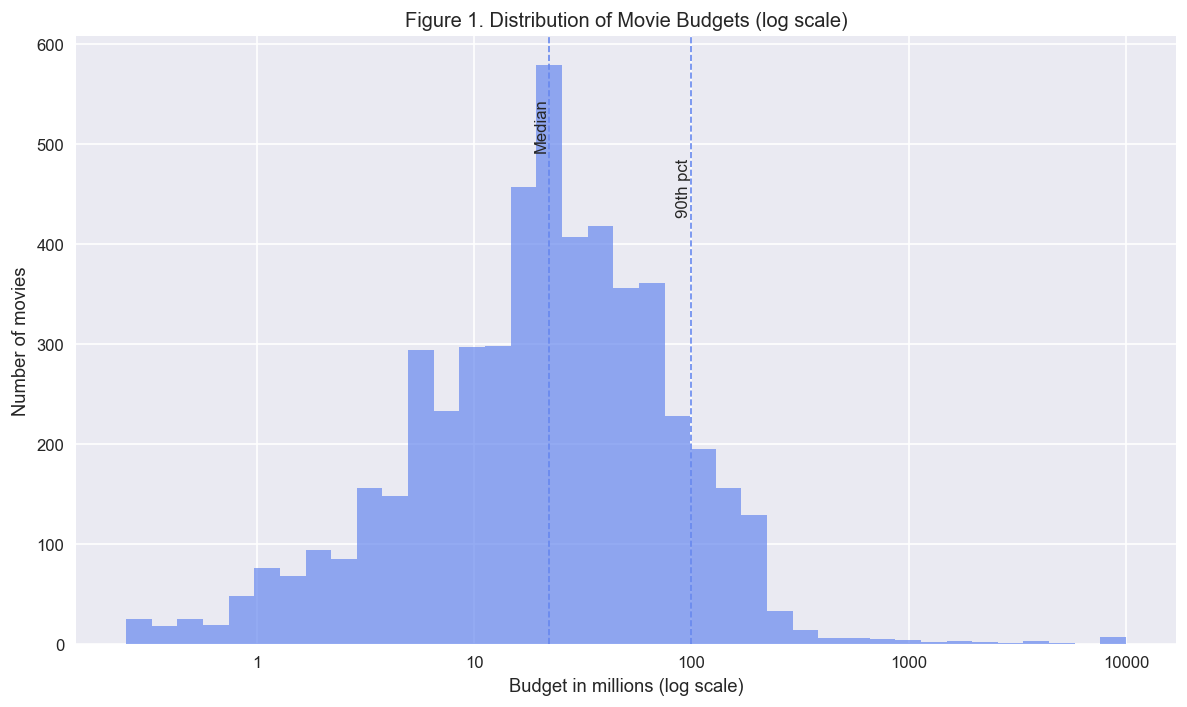

In [16]:
import numpy as np
from matplotlib.ticker import ScalarFormatter

# Work on a clean series
b = df['Budget (in millions)'].dropna()
b = b[b > 0]

# Use log-spaced bins so bars have equal width in log space
xmin = b.quantile(0.01)          # trim extreme tiny values for nicer axes
xmax = b.quantile(0.999)         # keep extreme outliers but avoid one bar dominating
bins = np.logspace(np.log10(xmin), np.log10(xmax), 40)

plt.figure(figsize=(10,6))
plt.hist(b.clip(upper=xmax), bins=bins, alpha=0.7, edgecolor='none')
plt.xscale('log')

# Reference lines
med = b.median()
p90 = b.quantile(0.90)
for v, lbl in [(med, "Median"), (p90, "90th pct")]:
    plt.axvline(v, linestyle='--', linewidth=1)
    plt.text(v, plt.ylim()[1]*0.90 if lbl=="Median" else plt.ylim()[1]*0.80,
             lbl, rotation=90, va='top', ha='right')

# Labels and formatting
plt.title("Figure 1. Distribution of Movie Budgets (log scale)")
plt.xlabel("Budget in millions (log scale)")
plt.ylabel("Number of movies")
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter())  # show 1, 10, 100, 1000 cleanly
plt.tight_layout()
plt.show()

**Interpretation:**  
Budgets are extremely right-skewed. The median is ≈ $22M, while the 90th percentile is far higher, confirming a small set of blockbusters that dominate spending. This skew motivates log scaling and non-parametric measures in the rest of the analysis.

## 2. Relationship Between Budget and Worldwide Gross

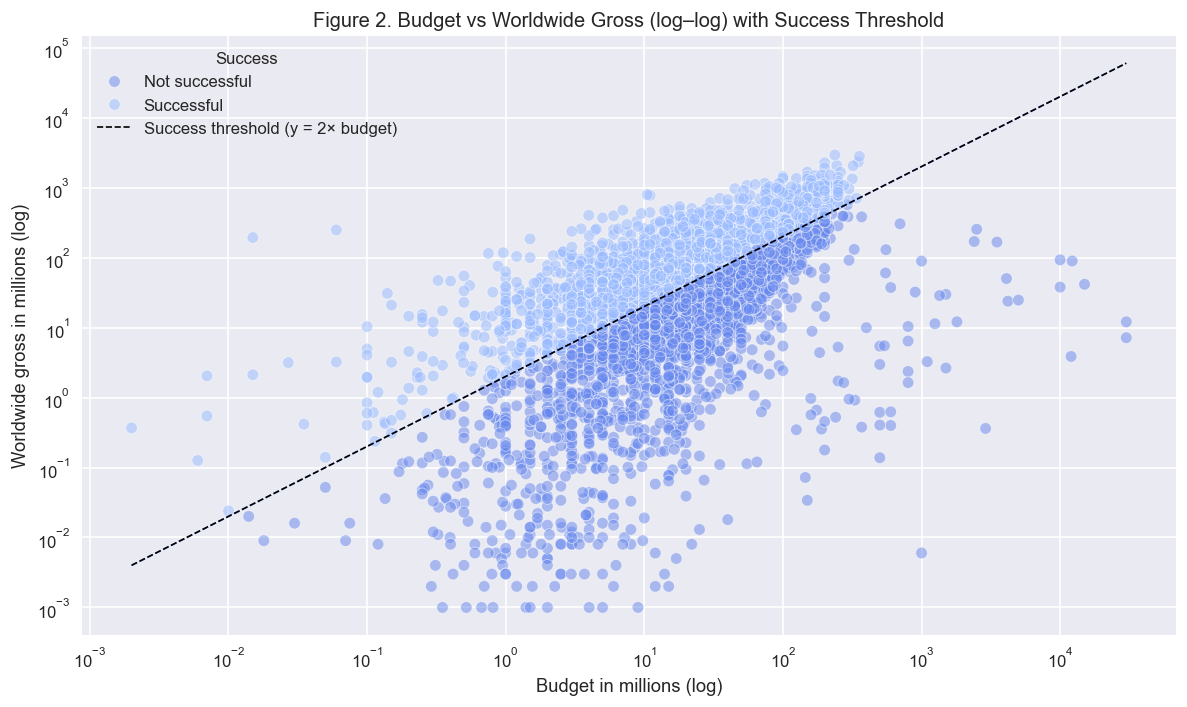

In [17]:
plt.figure(figsize=(10,6))

# Scatter
sns.scatterplot(
    x='Budget (in millions)', y='Gross worldwide (in millions)',
    hue=df['success'].map({0:'Not successful',1:'Successful'}),
    data=df, alpha=0.5, rasterized=True
)

# Log scales to spread the cloud
plt.xscale('log'); plt.yscale('log')

# Success threshold reference: y = 2x
x = np.logspace(np.log10(df['Budget (in millions)'].min()),
                np.log10(df['Budget (in millions)'].max()), 100)
plt.plot(x, 2*x, linestyle='--', linewidth=1)
ax = plt.gca()
(line,) = ax.plot(x, 2*x, linestyle='--', linewidth=1, color='black',
                  label='Success threshold (y = 2× budget)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [line], labels + ['Success threshold (y = 2× budget)'])

plt.title("Figure 2. Budget vs Worldwide Gross (log–log) with Success Threshold")
plt.xlabel("Budget in millions (log)")
plt.ylabel("Worldwide gross in millions (log)")
plt.legend(title="Success")
plt.tight_layout()
plt.show()

**Interpretation:**  
On log–log axes there is a clear positive relationship. The dashed line shows the success cutoff. Most successful films fall above that line, but there are notable low-budget successes and a few high-budget underperformers, which motivates modeling beyond budget alone.

## 3. Average Gross by Genre (top 10 genres)

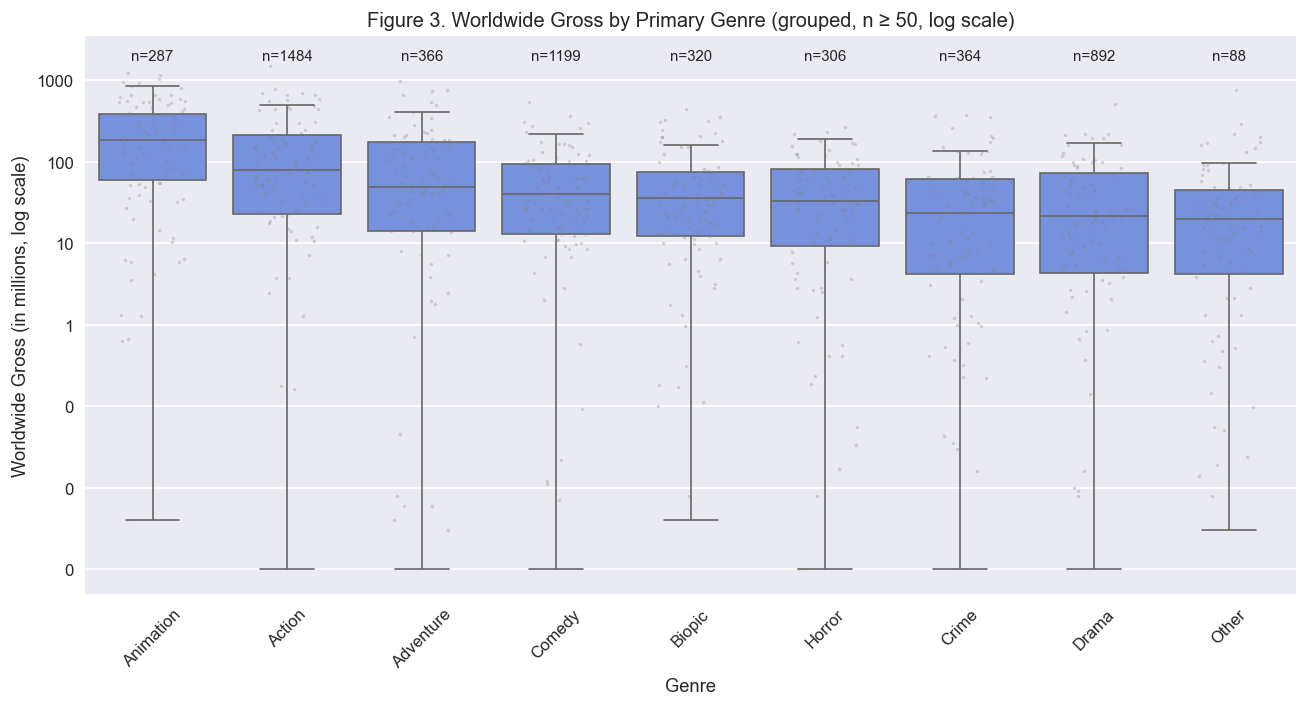

In [18]:
from matplotlib.ticker import ScalarFormatter
import seaborn as sns, matplotlib.pyplot as plt
import numpy as np

# use the grouped genre; fall back to Primary Genre if needed
GENRE_COL = 'Primary Genre (grouped)' if 'Primary Genre (grouped)' in df.columns else 'Primary Genre'

# keep only groups with n ≥ 50 (same rule as Fig 4)
min_n = 50
keep = df[GENRE_COL].value_counts()
keep = keep[keep >= min_n].index

dff = df[df[GENRE_COL].isin(keep)].copy()

# deterministic jitter sample: up to 80 pts per genre
dff_shuf = dff.sample(frac=1, random_state=42)
sampled = dff_shuf[dff_shuf.groupby(GENRE_COL, observed=True).cumcount() < 80]

# order boxes by median gross (desc) and put "Other" last if present
order = (dff.groupby(GENRE_COL, observed=True)['Gross worldwide (in millions)']
           .median().sort_values(ascending=False).index.tolist()
        )
if 'Other' in order:
    order = [g for g in order if g != 'Other'] + ['Other']

plt.figure(figsize=(11,6))
ax = sns.boxplot(
    x=GENRE_COL, y='Gross worldwide (in millions)',
    data=dff, order=order, showfliers=False
)

# light jitter points for texture
sns.stripplot(
    x=GENRE_COL, y='Gross worldwide (in millions)',
    data=sampled, order=order, size=2, alpha=0.3, color='gray', jitter=0.25
)

# log y-axis + readable ticks
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ScalarFormatter())

# headroom for n labels
low, high = ax.get_ylim()
ax.set_ylim(low, high*1.15)

# n labels per genre (using the filtered frame)
counts = dff[GENRE_COL].value_counts()
for i, g in enumerate(order):
    ax.text(i, ax.get_ylim()[1]*0.70, f"n={int(counts.get(g, 0))}",
            ha='center', va='top', fontsize=9)

plt.title("Figure 3. Worldwide Gross by Primary Genre (grouped, n ≥ 50, log scale)")
plt.xlabel("Genre")
plt.ylabel("Worldwide Gross (in millions, log scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Note:* "Other" aggregates primary genres with n < 50 to avoid sparse categories.

**Interpretation (updated):**  
Using grouped genres with a minimum of n ≥ 50 improves stability and aligns with Figure 4. Medians and IQRs (on a log scale) show substantial right-skew in grosses across all genres. **Animation** and **Action** have the highest typical (median) grosses with wide spreads, consistent with blockbuster-driven performance. **Drama** and **Comedy** show lower medians and tighter IQRs, reflecting smaller audiences/budgets. **Horror** and **Crime** have lower medians but occasional extreme hits. **Other** aggregates rare genres (n < 50), so its spread is broad and its median should be interpreted as a pooled summary rather than a coherent category. Boxplots emphasize typical outcomes (medians/IQRs); means can be dominated by a few outliers.

## 4. Success Rate by Genre

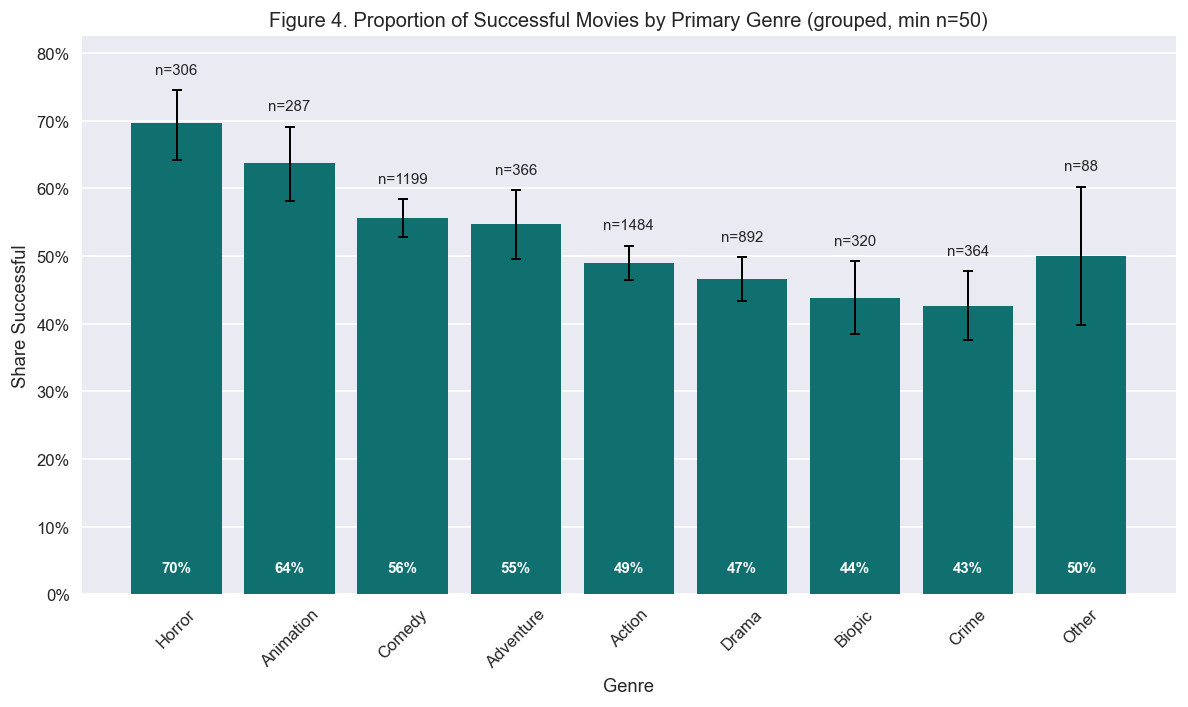

In [19]:
import numpy as np
from statsmodels.stats.proportion import proportion_confint
import matplotlib.ticker as mtick

# choose which genre column to use
GENRE_COL = 'Primary Genre (grouped)' if 'Primary Genre (grouped)' in df.columns else 'Primary Genre'

# success rate, n, and 95% CI per genre (min n=50)
g = df.groupby(GENRE_COL, observed=True)['success']
genre_binom = g.agg(rate='mean', n='size', k='sum').copy()
genre_binom = genre_binom[genre_binom['n'] >= 50]

# Wilson CIs
low, high = proportion_confint(genre_binom['k'], genre_binom['n'], method='wilson')
genre_binom['low'] = low
genre_binom['high'] = high

# Top 10 by success rate
top_rate = (genre_binom.sort_values('rate', ascending=False)
                        .head(10)
                        .reset_index()
                        .copy())

# detach from global categorical order and set explicit plotting order
top_rate[GENRE_COL] = top_rate[GENRE_COL].astype(str)

# keep order by rate but force "Other" (if present) to the far right
order = top_rate[GENRE_COL].tolist()
if "Other" in order:
    order = [g for g in order if g != "Other"] + ["Other"]
    
# reindex top_rate to match the plotting order so CIs/labels stay correct
top_rate = top_rate.set_index(GENRE_COL).loc[order].reset_index()

plt.figure(figsize=(10,6))
ax = sns.barplot(data=top_rate, x=GENRE_COL, y='rate', color='teal', order=order)

# visible CI caps
y = top_rate['rate'].to_numpy()
yerr = np.vstack([y - top_rate['low'].to_numpy(),
                  top_rate['high'].to_numpy() - y])
ax.errorbar(np.arange(len(order)), y, yerr=yerr,
            fmt='none', ecolor='black', elinewidth=1.2,
            capsize=3, capthick=1.2, zorder=5)

# percent axis + headroom
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, min(1, float(top_rate['high'].max()) + 0.08))

# n labels above CIs
for i, r in top_rate.iterrows():
    ax.text(i, min(0.98, float(r['high']) + 0.02),
            f"n={int(r['n'])}", ha='center', va='bottom', fontsize=9)

# % labels
ymin, ymax = ax.get_ylim()
y_text = ymin + (ymax - ymin) * 0.035

for p, r in zip(ax.patches, top_rate.itertuples()):
    x = p.get_x() + p.get_width()/2
    ax.text(
        x, y_text, f"{r.rate*100:.0f}%",
        ha='center', va='bottom',
        fontsize=9, color='white', fontweight='bold',
        zorder=6
    )

plt.title("Figure 4. Proportion of Successful Movies by Primary Genre (grouped, min n=50)")
plt.xlabel("Genre"); plt.ylabel("Share Successful")
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

*Note:* "Other" aggregates primary genres with n < 50 to avoid sparse categories.

**Interpretation (updated):**  
Using grouped primary genres with a minimum of n ≥ 50, **Horror** shows the highest success share (≈70%). **Animation** is also elevated (≈64%). A middle cluster (**Comedy** ≈56%, **Adventure** ≈55%, **Action** ≈49%) sits around the 50–55% range. **Drama** (≈47%), **Biopic** (≈44%), and **Crime** (≈43%) are lower. The **“Other”** category aggregates rare genres (n < 50), so its share (≈50%) has the widest confidence interval and should be read as a pooled average rather than a single coherent genre.

Error bars are 95% Wilson CIs; overlapping intervals indicate differences may not be statistically distinguishable at that confidence level. The ordering is consistent with the 2× budget success definition and remains similar under the 1.5×–3× sensitivity checks reported earlier.

## 5. Correlation Heatmap of Numeric Features

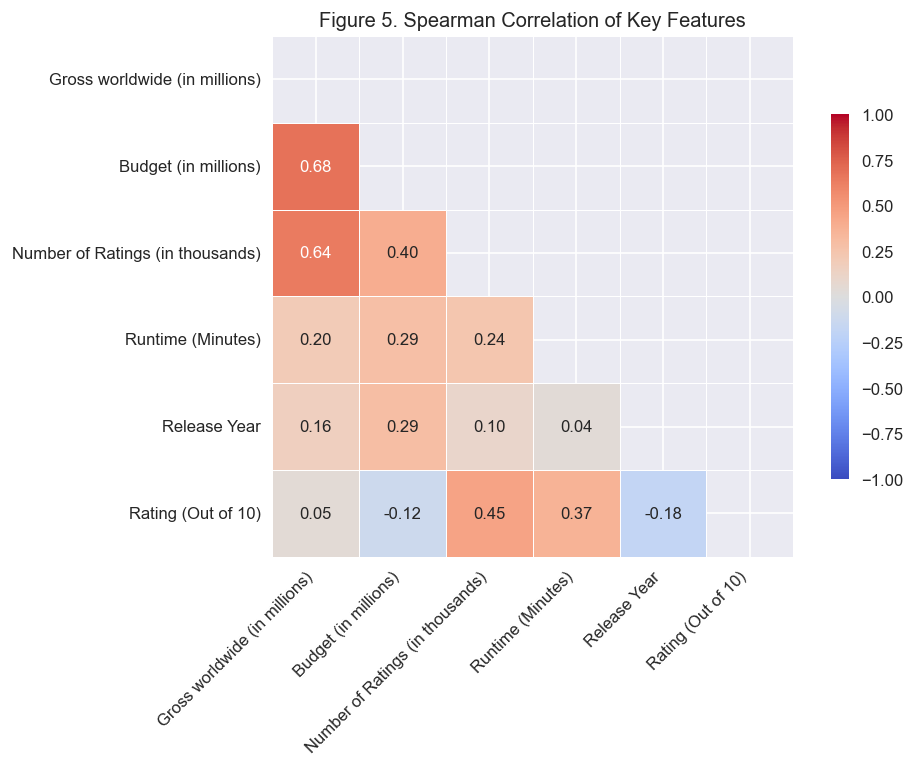

In [20]:
import numpy as np

cols = ['Budget (in millions)','Gross worldwide (in millions)',
        'Rating (Out of 10)','Number of Ratings (in thousands)',
        'Runtime (Minutes)','Release Year']

corr = df[cols].corr(method='spearman')
order = corr['Gross worldwide (in millions)'].abs().sort_values(ascending=False).index
corr = corr.reindex(index=order, columns=order)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8.5,6.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap='coolwarm', vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': .7}, linewidths=.5, linecolor='white')
plt.title("Figure 5. Spearman Correlation of Key Features")
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

*Note:* Gross is included in the heatmap for context only; it is the target and will not be used as a predictor.

**Interpretation:**  
Budget and worldwide gross show the strongest association, which is expected as production scale and marketing typically move with revenue. Audience engagement, proxied by number of ratings, also aligns with higher revenue. Ratings are only modestly related, and runtime and release year are weak. Spearman is appropriate here because financial variables are heavily skewed; it captures monotonic patterns that Pearson can understate.

## 5. Summary of Insights

The exploratory analysis surfaces several consistent patterns.

- **Heavy skew in spend and returns:** Budgets and worldwide grosses are concentrated at modest levels with a long right tail, which is why log scales were necessary to see typical behavior. A small set of blockbusters accounts for the extreme values.

- **Budget vs gross is monotonic, not deterministic:** On log-log axes, higher budgets usually align with higher grosses, yet many low and mid-budget titles outperform expectations and a few large budgets underperform. The success threshold line makes this visible. Because success is defined relative to budget, raw budget level is only weakly correlated with success, since higher budgets raise both costs and expected gross.

- **Genre matters in two ways:** Boxplots show higher typical (median) grosses for Animation and Action, while the success-rate chart with a minimum sample size filter shows Horror, Animation, and Action leading on probability of success. Counts and confidence intervals indicate that estimates are more stable for high-volume genres like Action and Comedy.

- **Audience engagement aligns with revenue:** Spearman correlations highlight budget and number of ratings as the strongest associates with gross. Ratings are only moderately related, and runtime and release year are weak.

**Implications for modeling:**  
I will use only information available before release: log(budget), primary genre (grouped and one-hot encoded), runtime, motion picture rating, and release year to absorb time effects. I will exclude IMDb user rating and number of ratings, as well as any gross or opening-weekend fields, to avoid leakage. I will test interactions (e.g., budget × genre) and non-linearities with a tree-based model.

**Limitations and sensitivity:**  
Results are not inflation adjusted, budgets can be noisy across sources, and multi-genre titles were simplified to a primary genre. The profitability rule uses a 2x budget threshold; a quick share check shows patterns are robust across 1.5x to 3.0x cutoffs.

**Next steps:**  
Proceed to preprocessing and model building in Milestone 2: encode the grouped primary genre; add `log(budget)`; keep runtime, motion picture rating, and release year; then train a baseline logistic regression and a tree-based model. Use a stratified train–test split and report accuracy, ROC-AUC, precision, recall, F1, and calibration. Consider interaction terms (e.g., budget × genre) and non-linear effects.

# Milestone 2: Data Preparation

### 1. Objective and Plan
Prepare a modeling-ready table using **pre-release features only** (guardrail: no post-release signals like grosses, opening weekend, IMDb rating, or vote counts). **This follows the Milestone 1 feedback to use only information available before release.**

**Feature set used here:** Budget, Runtime (Minutes), Release Year, Motion Picture Rating, and Primary Genre (grouped).  
**Steps:** (i) select and justify features, (ii) transform and engineer (`log_budget`, grouped genres), (iii) encode categoricals, (iv) stratified split, (v) export artifacts for Milestone 3.

In [1]:
# Reproducibility & styling (same as Milestone 1)
import numpy as np, random, sys, platform, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

np.random.seed(42); random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8')
sns.set_palette("coolwarm")

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | Platform {platform.platform()}")

Python 3.11.11 | pandas 2.3.1 | Platform Windows-10-10.0.26200-SP0


In [2]:
# Helper to keep captions consistent
from IPython.display import Markdown, display

_fig = {"n": 0}
def caption(text):
    _fig["n"] += 1
    display(Markdown(f"**Figure {_fig['n']}. {text}**"))

### 2. Load Clean Input and Quick Audit
We load the file saved at the end of Milestone 1; if missing, we fall back to the base clean CSV and recreate engineered fields.

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

# Prefer the M1 export; otherwise use the base clean file
if Path("IMDbMovies-Clean_ready.csv").exists():
    df = pd.read_csv("IMDbMovies-Clean_ready.csv")
else:
    df = pd.read_csv("IMDbMovies-Clean.csv")

# Keep Release Year readable/numeric (avoids 2,023.00 in tables)
df['Release Year'] = pd.to_numeric(df['Release Year'], errors='coerce').astype('Int64')

print("Shape:", df.shape)
df.head()

Shape: (5306, 18)


,Title,Summary,Director,Writer,Main Genres,Motion Picture Rating,Release Year,Runtime (Minutes),Rating (Out of 10),Number of Ratings (in thousands),Budget (in millions),Gross in US & Canada (in millions),Gross worldwide (in millions),Opening Weekend in US & Canada,Gross Opening Weekend (in millions),success,Primary Genre,Primary Genre (grouped)
0,The Hunger Games: The Ballad of Songbirds & Sn...,Coriolanus Snow mentors and develops feelings ...,Francis Lawrence,"Michael Lesslie,Michael Arndt,Suzanne Collins","Action,Adventure,Drama",PG-13,2023,157.00,7.20,37.00,100.00,105.04,191.73,11.19.2023,44.61,0,Action,Action
1,Oppenheimer,"The story of American scientist, J. Robert Opp...",Christopher Nolan,"Martin Sherwin,Christopher Nolan,Kai Bird","Biography,Drama,History",R,2023,3.00,8.50,525.00,100.00,325.37,950.55,07.23.2023,82.45,1,Biopic,Biopic
2,The Marvels,Carol Danvers gets her powers entangled with t...,Nia DaCosta,"Elissa Karasik,Nia DaCosta,Megan McDonnell","Action,Adventure,Fantasy",PG-13,2023,105.00,6.00,57.00,220.00,77.93,188.20,11.12.2023,46.11,0,Action,Action
3,Wish,A young girl named Asha wishes on a star and g...,"Fawn Veerasunthorn,Chris Buck","Jennifer Lee,Chris Buck,Allison Moore","Animation,Adventure,Comedy",PG,2023,95.00,5.90,6.40,200.00,33.97,51.28,11.26.2023,19.70,0,Animation,Animation
4,The Creator,Against the backdrop of a war between humans a...,Gareth Edwards,"Chris Weitz,Gareth Edwards","Action,Adventure,Drama",PG-13,2023,133.00,6.90,79.00,80.00,40.77,104.18,10.01.2023,14.08,0,Action,Action


In [4]:
# --- Ensure core engineered fields exist (idempotent & guardrail-safe) ---

# success target (2× budget rule) — only if missing
if 'success' not in df.columns:
    for col in ["Budget (in millions)", "Gross worldwide (in millions)"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["Budget (in millions)", "Gross worldwide (in millions)"])
    df = df[(df["Budget (in millions)"] > 0) & (df["Gross worldwide (in millions)"] > 0)]
    df["success"] = (df["Gross worldwide (in millions)"] >= 2*df["Budget (in millions)"]).astype(int)

# primary genre (first listed) — only if missing
if 'Primary Genre' not in df.columns:
    df['Primary Genre'] = (df['Main Genres'].fillna('Unknown')
                           .astype(str).str.split(',').str[0].str.strip())

# grouped primary genre (n ≥ 50, else 'Other') — only if missing
if 'Primary Genre (grouped)' not in df.columns:
    min_n = 50
    keep = df['Primary Genre'].value_counts()
    keep = keep[keep >= min_n].index
    df['Primary Genre (grouped)'] = df['Primary Genre'].where(df['Primary Genre'].isin(keep), 'Other')
else:
    # if it already exists, rebuild the keep index for category ordering below
    min_n = 50
    keep = df['Primary Genre'].value_counts()
    keep = keep[keep >= min_n].index

# freeze category order USING THE KEPT SET (plus 'Other' last)
cats = sorted(keep.tolist())
if "Other" not in cats:
    cats = cats + ["Other"]
df['Primary Genre (grouped)'] = pd.Categorical(df['Primary Genre (grouped)'],
                                               categories=cats, ordered=True)

# Normalize MPAA / content rating, make categorical (stable dummies later)
df['Motion Picture Rating'] = (df['Motion Picture Rating']
                               .fillna('Unrated')
                               .astype(str)
                               .str.strip())
df['Motion Picture Rating'] = pd.Categorical(df['Motion Picture Rating'])

In [5]:
# Quick audit of grouped-genre counts
vc = df['Primary Genre (grouped)'].value_counts()
display(vc.to_frame('count').head(12))

,count
Primary Genre (grouped),
Action,1484
Comedy,1199
Drama,892
Adventure,366
Crime,364
Biopic,320
Horror,306
Animation,287
Other,88


*Note:* "Other" aggregates primary genres with n < 50 to avoid sparse categories.

**Interpretation:**  
Dataset loaded and core engineered fields are present. `Release Year` coerced to integer; primary genres grouped at n ≥ 50 with 'Other' last; MPAA rating normalized and set to categorical.

### 3. Feature Selection (pre-release guardrail)
**Kept (pre-release):** Budget, Runtime, Release Year, Motion Picture Rating, Primary Genre (grouped).  
**Dropped (post-release / target-adjacent):** All gross and opening-weekend fields, IMDb user rating, and vote counts.

In [6]:
# Define allowed features (pre-release only) and freeze the modeling frame for M2
safe_pool = [
    'Budget (in millions)', 'Runtime (Minutes)', 'Release Year',
    'Motion Picture Rating', 'Primary Genre (grouped)', 'success'
]
forbidden = {
    'Gross worldwide (in millions)', 'Gross in US & Canada (in millions)',
    'Gross Opening Weekend (in millions)', 'Opening Weekend in US & Canada',
    'Rating (Out of 10)', 'Number of Ratings (in thousands)'
}

# Safety check: ensure no leakage fields slip in
assert not (set(safe_pool) & forbidden), "Forbidden (post-release) field in safe_pool!"

df_prep = df[safe_pool].copy()

# Keep Release Year readable as integer in this working frame
df_prep['Release Year'] = pd.to_numeric(df_prep['Release Year'], errors='coerce').astype('Int64')

print("Prep frame:", df_prep.shape)
df_prep.head(2)

Prep frame: (5306, 6)


,Budget (in millions),Runtime (Minutes),Release Year,Motion Picture Rating,Primary Genre (grouped),success
0,100.00,157.00,2023,PG-13,Action,0
1,100.00,3.00,2023,R,Biopic,1


In [7]:
# Quick NA audit on required fields for downstream modeling
na = df_prep[['Budget (in millions)', 'Runtime (Minutes)', 'Release Year',
              'Motion Picture Rating', 'Primary Genre (grouped)', 'success']].isna().sum()
display(na.to_frame('missing'))

,missing
Budget (in millions),0
Runtime (Minutes),1
Release Year,0
Motion Picture Rating,0
Primary Genre (grouped),0
success,0


In [8]:
# Handle the lone missing runtime (median imputation) and lock categorical dtypes
runtime_med = df_prep['Runtime (Minutes)'].median()
imputed_n = int(df_prep['Runtime (Minutes)'].isna().sum())
df_prep['Runtime (Minutes)'] = df_prep['Runtime (Minutes)'].fillna(runtime_med)

# Ensure stable dummies later
df_prep['Motion Picture Rating']   = df_prep['Motion Picture Rating'].astype('category')
df_prep['Primary Genre (grouped)'] = df_prep['Primary Genre (grouped)'].astype('category')

# Quick NA re-check
na_after = df_prep[['Budget (in millions)', 'Runtime (Minutes)', 'Release Year',
                    'Motion Picture Rating', 'Primary Genre (grouped)', 'success']].isna().sum()
display(na_after.to_frame('missing'))

,missing
Budget (in millions),0
Runtime (Minutes),0
Release Year,0
Motion Picture Rating,0
Primary Genre (grouped),0
success,0


**Interpretation (updated):**  
Imputed **1** missing value in `Runtime (Minutes)` with the median to keep the row without introducing outliers. Cast MPAA rating and grouped genre to `category` to stabilize one-hot encoding in the next section.

### 4. Transform & Engineer
We stabilize extreme skew in budgets and keep time effects explicit.

In [9]:
import numpy as np

# Log-transform budget for modeling; keep raw budget as context
# (clip is harmless safety; budgets are already >0 after cleaning)
df_prep['log_budget'] = np.log1p(df_prep['Budget (in millions)'].clip(lower=1e-6))

# Decade bin; keep Year too
df_prep['Release Decade'] = (df_prep['Release Year'] // 10) * 10
df_prep['Release Decade'] = df_prep['Release Decade'].astype('Int64')

# Categorical dtypes for stable dummy order
df_prep['Motion Picture Rating']   = df_prep['Motion Picture Rating'].astype('category')
df_prep['Primary Genre (grouped)'] = df_prep['Primary Genre (grouped)'].astype('category')

**Interpretation:**  
Added `log_budget` to address heavy right skew; `Release Decade` is optional for coarse time effects and kept as integer. Categorical dtypes ensure stable one-hot columns.

In [10]:
# Quick QA: preview new columns and basic checks
display(df_prep[['Budget (in millions)','log_budget','Release Year','Release Decade']].head())

log_stats = df_prep['log_budget'].describe().round(2)
decade_counts = df_prep['Release Decade'].value_counts().sort_index()

display(log_stats.to_frame('log_budget'))
display(decade_counts.to_frame('n'))

,Budget (in millions),log_budget,Release Year,Release Decade
0,100.00,4.62,2023,2020
1,100.00,4.62,2023,2020
2,220.00,5.40,2023,2020
3,200.00,5.30,2023,2020
4,80.00,4.39,2023,2020


,log_budget
count,"5,306.00"
mean,3.07
std,1.27
min,0.00
25%,2.25
50%,3.14
75%,3.93
max,10.31


,n
Release Decade,
1920,6
1930,17
1940,28
1950,55
1960,87
1970,182
1980,570
1990,903
2000,1390


**Interpretation:**  
`log_budget` shows a tighter, more symmetric range; `Release Decade` counts confirm bins are populated and ordered.

### 5. Encode Categoricals (dummies)
Create one-hot variables for MPAA rating and grouped genre (rare categories already pooled as **Other** in M1).

In [11]:
# Build modeling matrix X and target y
num_cols = ['log_budget', 'Runtime (Minutes)', 'Release Year']
cat_cols = ['Primary Genre (grouped)', 'Motion Picture Rating']

X_num = df_prep[num_cols].copy().reset_index(drop=True)
X_cat = pd.get_dummies(
    df_prep[cat_cols],
    prefix=['genre', 'mpa'],
    drop_first=True,
    dtype=np.uint8            # keep dummies explicitly numeric
).reset_index(drop=True)

X = pd.concat([X_num, X_cat], axis=1)
y = df_prep['success'].astype(int).reset_index(drop=True)

feature_names = X.columns.tolist()

print("X shape:", X.shape, "| y shape:", y.shape)
X.head(3)

X shape: (5306, 29) | y shape: (5306,)


,log_budget,Runtime (Minutes),Release Year,genre_Adventure,genre_Animation,genre_Biopic,genre_Comedy,genre_Crime,genre_Drama,genre_Horror,genre_Other,mpa_16+,mpa_18+,mpa_Approved,mpa_G,mpa_GP,mpa_M,mpa_M/PG,mpa_NC-17,mpa_Not Rated,mpa_PG,mpa_PG-13,mpa_Passed,mpa_R,mpa_TV-14,mpa_TV-MA,mpa_TV-PG,mpa_Unrated,mpa_X
0,4.62,157.00,2023,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,4.62,3.00,2023,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,5.40,105.00,2023,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [12]:
# Sanity checks: no missing, no zero-variance columns
missing_total = int(X.isna().sum().sum())
zero_var = X.columns[(X.nunique(dropna=False) <= 1)].tolist()

print(f"Missing values in X: {missing_total}")
print(f"Zero-variance columns: {zero_var if zero_var else 'None'}")

Missing values in X: 0
Zero-variance columns: None


**Interpretation:**  
One-hot encoding applied with `drop_first=True` to avoid perfect multicollinearity. Dummies are stored as numeric (uint8), and a quick audit confirms no missing values or degenerate columns. `feature_names` saved for later model reporting.

### 6. Stratified Train/Test Split (for Milestone 3)
We hold out 25% for final evaluation while preserving class balance.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42,
)

print("Stratified split random_state =", 42)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
p_train, p_test = y_train.mean(), y_test.mean()
print("Success share (train/test):", round(p_train, 3), round(p_test, 3))

# Guardrail: ensure stratification preserved class balance
delta = abs(p_train - p_test)
assert delta <= 0.02, f"Class proportion drift too high: Δ={delta:.3f}"

# Simple baseline for later comparison (majority class in train)
baseline_acc = max(p_train, 1 - p_train)
print(f"Baseline (majority-class) accuracy, train: {baseline_acc:.3f}")

Stratified split random_state = 42
Train: (3979, 29) | Test: (1327, 29)
Success share (train/test): 0.517 0.517
Baseline (majority-class) accuracy, train: 0.517


**Interpretation:**  
Stratification preserves class balance (Δ ≤ 2%). Reporting a majority-class baseline now provides a reference for Milestone 3 model performance.

### 7. Quick Diagnostics

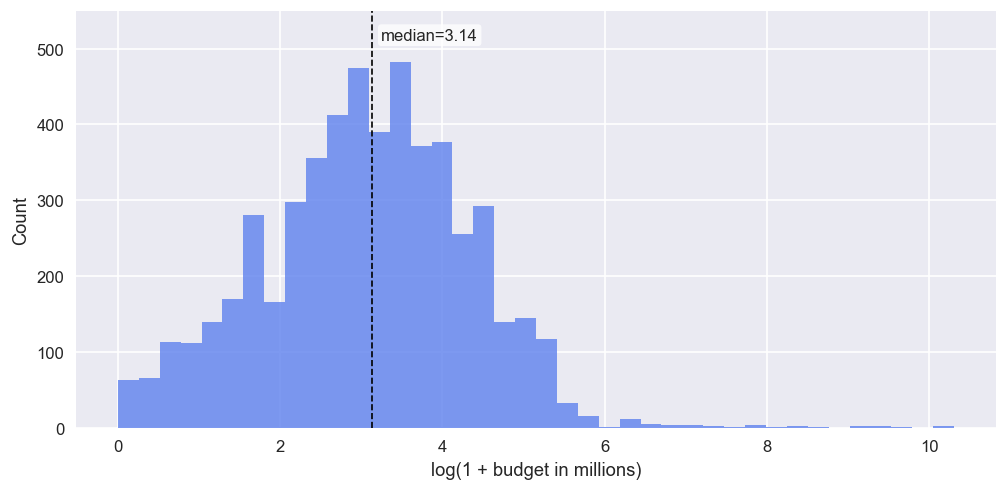

**Figure 1. Distribution of log(budget)**

In [14]:
# Figure 1. Distribution of log(budget) with median
fig, ax = plt.subplots(figsize=(8.5, 4.2))

vals = df_prep['log_budget'].dropna().to_numpy()
n, _, _ = ax.hist(vals, bins=40, alpha=0.85)

median_lb = np.median(vals)
ax.axvline(median_lb, color='black', linestyle='--', linewidth=1, zorder=5)

ymax = max(n)
ax.set_ylim(0, ymax * 1.14)
xl = ax.get_xlim()
x_offset = 0.01 * (xl[1] - xl[0])
ax.text(
    median_lb + x_offset,
    ax.get_ylim()[1] * 0.96,
    f"median={median_lb:.2f}",
    ha='left', va='top', fontsize=10,
    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.75),
    zorder=6
)

ax.set_xlabel("log(1 + budget in millions)")
ax.set_ylabel("Count")
plt.tight_layout(); plt.show()
caption("Distribution of log(budget)")

**Interpretation:**  
Log transform produces a tighter, more symmetric spread; the dashed line shows the median.

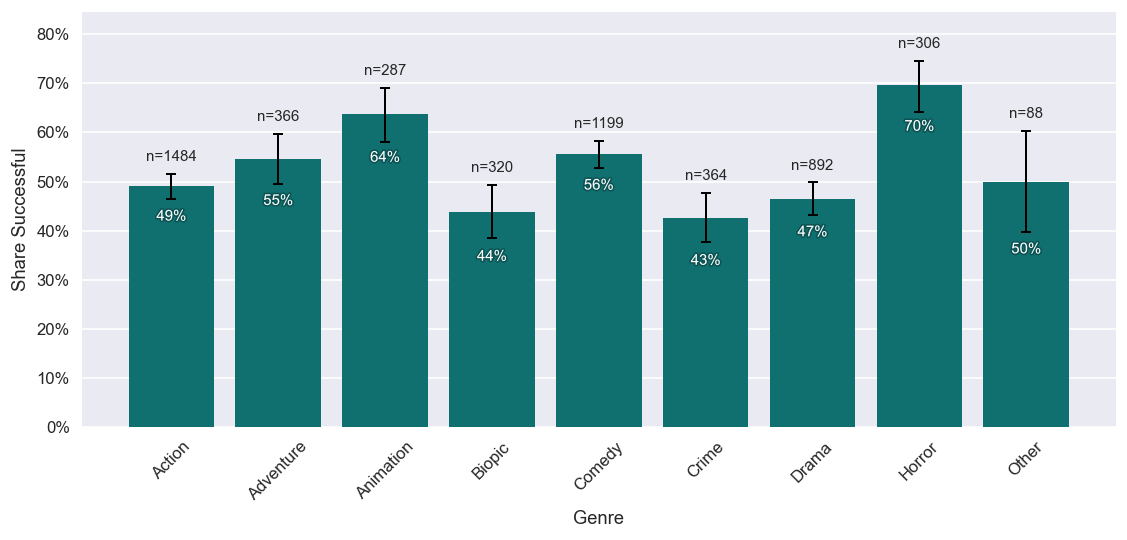

**Figure 2. Success rate by grouped primary genre**

In [15]:
# Figure 2. Success rate by grouped primary genre (Wilson CIs, n and % labels)
import numpy as np
import matplotlib.ticker as mtick
from statsmodels.stats.proportion import proportion_confint
import matplotlib.patheffects as pe

# Order: all categories except 'Other', then 'Other'
cats = [c for c in df_prep['Primary Genre (grouped)'].cat.categories if c != 'Other'] + ['Other']

g = df_prep.groupby('Primary Genre (grouped)', observed=True)['success']
tbl = g.agg(rate='mean', n='size', k='sum').reindex(cats)

# Wilson confidence intervals
low, high = proportion_confint(tbl['k'], tbl['n'], method='wilson')
tbl['low'], tbl['high'] = low, high

plt.figure(figsize=(9.5, 4.6))
ax = sns.barplot(x=tbl.index, y=tbl['rate'], color='teal', order=cats)

# Error bars with caps
y = tbl['rate'].to_numpy()
yerr = np.vstack([y - tbl['low'].to_numpy(), tbl['high'].to_numpy() - y])
ax.errorbar(
    x=np.arange(len(cats)), y=y, yerr=yerr,
    fmt='none', ecolor='black', capsize=3, elinewidth=1.2, capthick=1.2, zorder=5
)

# Percent y-axis and slight headroom
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, min(1, float(tbl['high'].max()) + 0.1))

# Annotate n above CI and % inside bar (bottom)
for i, r in enumerate(tbl.itertuples()):
    # keep the n above the CI
    ax.text(i, min(0.98, float(r.high) + 0.02), f"n={int(r.n)}",
            ha='center', va='bottom', fontsize=9, zorder=6)
    clearance = float(r.high - r.rate) + 0.05
    y_pct = max(0.03, float(r.rate) - max(0.06, clearance))
    ax.text(i, y_pct, f"{float(r.rate):.0%}",
            ha='center', va='bottom', fontsize=9, color='white',
            path_effects=[pe.withStroke(linewidth=2, foreground='black', alpha=0.25)],
            zorder=6)

plt.xlabel("Genre"); plt.ylabel("Share Successful")
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()
caption("Success rate by grouped primary genre")

*Note:* Chart uses only pre-release features (no grosses, ratings, or vote counts). "Other" aggregates primary genres with n < 50 to avoid sparse categories.

**Interpretation:**  
Patterns match Milestone 1: Horror is elevated, Animation strong; mid-pack genres cluster around ~50–55%. Wilson CIs reflect binomial uncertainty; overlapping intervals shouldn’t be read as definitive differences.

### 8. Export Artifacts (for Milestone 3)

In [16]:
from pathlib import Path
import numpy as np
import pandas as pd

out = Path("m2_exports")
out.mkdir(exist_ok=True)

# Ensure y is a pandas Series with a name
if isinstance(y, np.ndarray):
    y_series = pd.Series(y, name="y")
else:
    y_series = y.copy()
    if y_series.name is None:
        y_series.name = "y"

if isinstance(y_train, np.ndarray):
    y_train_series = pd.Series(y_train, name="y_train")
else:
    y_train_series = y_train.copy().rename("y_train")

if isinstance(y_test, np.ndarray):
    y_test_series = pd.Series(y_test, name="y_test")
else:
    y_test_series = y_test.copy().rename("y_test")

# ---- Parquet (preferred: smaller, preserves dtypes) ----
X.to_parquet(out / "X.parquet")
y_series.to_frame().to_parquet(out / "y.parquet")
X_train.to_parquet(out / "X_train.parquet")
X_test.to_parquet(out / "X_test.parquet")
y_train_series.to_frame().to_parquet(out / "y_train.parquet")
y_test_series.to_frame().to_parquet(out / "y_test.parquet")
df_prep.to_parquet(out / "prepared_dataset.parquet")

# Save feature names for model reporting
display(pd.Series(feature_names, name="feature"))
pd.Series(feature_names, name="feature").to_frame().to_csv(out / "feature_names.csv", index=False)

# ---- Also export as CSV for easy inspection ----
X.to_csv(out / "model_X.csv", index=False)
y_series.to_csv(out / "model_y.csv", index=False)
X_train.to_csv(out / "train_X.csv", index=False)
X_test.to_csv(out / "test_X.csv", index=False)
y_train_series.to_csv(out / "train_y.csv", index=False)
y_test_series.to_csv(out / "test_y.csv", index=False)
df_prep.to_csv(out / "prepared_dataset.csv", index=False)

print("Saved artifacts to", out.resolve())

# --- Round-trip smoke test ---
import pandas as pd
from pathlib import Path

out = Path("m2_exports")

Xp = pd.read_parquet(out / "X.parquet")
yp = pd.read_parquet(out / "y.parquet")["y"]
Xtr = pd.read_parquet(out / "X_train.parquet")
Xte = pd.read_parquet(out / "X_test.parquet")
ytr = pd.read_parquet(out / "y_train.parquet")["y_train"]
yte = pd.read_parquet(out / "y_test.parquet")["y_test"]

print("X / y:", Xp.shape, len(yp))
print("train:", Xtr.shape, ytr.mean().round(3))
print("test :", Xte.shape, yte.mean().round(3))
assert Xp.shape[1] == len(pd.read_csv(out / "feature_names.csv"))

import json, sys, platform
meta = {
    "python": sys.version.split()[0],
    "pandas": pd.__version__,
    "platform": platform.platform(),
    "X_shape": X.shape,
    "y_len": int(len(y_series)),
    "X_train_shape": X_train.shape,
    "X_test_shape": X_test.shape,
    "y_train_len": int(len(y_train_series)),
    "y_test_len": int(len(y_test_series)),
    "success_rate_train": float(y_train_series.mean()),
    "success_rate_test": float(y_test_series.mean()),
    "n_features": len(pd.read_csv(out / "feature_names.csv")),
}
with open(out / "meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Wrote", (out / "meta.json").resolve())

0            log_budget
1     Runtime (Minutes)
2          Release Year
3       genre_Adventure
4       genre_Animation
5          genre_Biopic
6          genre_Comedy
7           genre_Crime
8           genre_Drama
9          genre_Horror
10          genre_Other
11              mpa_16+
12              mpa_18+
13         mpa_Approved
14                mpa_G
15               mpa_GP
16                mpa_M
17             mpa_M/PG
18            mpa_NC-17
19        mpa_Not Rated
20               mpa_PG
21            mpa_PG-13
22           mpa_Passed
23                mpa_R
24            mpa_TV-14
25            mpa_TV-MA
26            mpa_TV-PG
27          mpa_Unrated
28                mpa_X
Name: feature, dtype: object

Saved artifacts to C:\Users\csar3\miniconda3\envs\book_env\DSC550\m2_exports
X / y: (5306, 29) 9
train: (3979, 29) 0.517
test : (1327, 29) 0.517
Wrote C:\Users\csar3\miniconda3\envs\book_env\DSC550\m2_exports\meta.json


**Interpretation:**  
Artifacts for Milestone 3 were exported to `m2_exports/` in Parquet (model-ready, dtype-preserving) and CSV (for inspection). A quick round-trip load confirms shapes and success-class balance match Section 6. `feature_names.csv` provides the column order for reporting and model introspection.

## Section Summary

- Features limited to **pre-release** signals; rare genres grouped into **Other**.  
- Budgets stabilized with a log1p transform; categoricals one-hot encoded.  
- **Stratified** train/test split keeps success rate consistent across folds.  
- Artifacts exported (Parquet + CSV) for a reproducible Milestone 3 load.  
- Ready to train logistic and tree-based baselines and report accuracy, ROC–AUC, precision, recall, F1, and calibration.

# Milestone 3: Model Building and Evaluation

**Goal:** train and evaluate at least one model using **pre-release** features only.  
**Models:** Majority baseline, Logistic Regression, Random Forest.  
**Metrics:** accuracy, ROC-AUC, precision, recall, F1; plus calibration and threshold tuning.

## Imports, constants, and load data

Load the Milestone 2 exports built from **pre-release features only**, then do quick sanity checks so modeling starts clean.

**What this cell does**
- Loads `train_X.csv`, `test_X.csv`, `train_y.csv`, `test_y.csv` from `m2_exports/`
- Verifies there are **no post-release fields** (grosses, opening weekend, IMDb rating/votes)
- Ensures train/test have **identical columns in the same order**
- Confirms numeric fields are numeric and **NA-free**
- Casts one-hot/dummy columns to `uint8` (keeps memory small)
- Checks the stratified split kept class balance (Δ ≤ 0.02)

**Guardrails / leakage checks**
- Forbidden columns: *Gross worldwide*, *Gross in US & Canada*, *Opening Weekend*, *Rating (Out of 10)*, *Number of Ratings (in thousands)*
- If any are found in X, the cell raises an error and stops.

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, confusion_matrix
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score

# reproducibility / display
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.options.display.float_format = '{:.3f}'.format

# load M2 artifacts
exp = Path("m2_exports")
if not exp.exists():
    raise FileNotFoundError("m2_exports/ not found. Re-run M2 export or copy files here.")

X_train = pd.read_csv(exp / "train_X.csv", low_memory=False)
X_test  = pd.read_csv(exp / "test_X.csv",  low_memory=False)
y_train = pd.read_csv(exp / "train_y.csv").squeeze("columns")
y_test  = pd.read_csv(exp / "test_y.csv").squeeze("columns")

# guardrail: no post-release fields
forbidden = {
    'Gross worldwide (in millions)',
    'Gross in US & Canada (in millions)',
    'Opening Weekend in US & Canada',
    'Rating (Out of 10)',
    'Number of Ratings (in thousands)'
}
bad_train = set(X_train.columns) & forbidden
bad_test  = set(X_test.columns) & forbidden
assert not bad_train, f"Leakage in X_train: {bad_train}"
assert not bad_test,  f"Leakage in X_test: {bad_test}"

# guardrail: train/test columns must match and be in the same order
if set(X_train.columns) != set(X_test.columns):
    raise ValueError(
        f"Train/Test columns differ.\n"
        f"Only in train: {set(X_train.columns)-set(X_test.columns)}\n"
        f"Only in test : {set(X_test.columns)-set(X_train.columns)}"
    )
X_test = X_test[X_train.columns]  # enforce identical order

# numeric columns should be numeric and NA-free
num_cols = ['log_budget', 'Runtime (Minutes)', 'Release Year']
for df_ in (X_train, X_test):
    df_[num_cols] = df_[num_cols].apply(pd.to_numeric, errors='coerce')

na_train = X_train[num_cols].isna().sum().sum()
na_test  = X_test[num_cols].isna().sum().sum()
assert na_train == 0 and na_test == 0, f"NA in numeric columns — train={na_train}, test={na_test}"

# store dummies as uint8 to keep memory in check
dummy_like = [c for c in X_train.columns if X_train[c].dropna().isin([0, 1]).all()]
for c in dummy_like:
    X_train[c] = X_train[c].astype('uint8')
    X_test[c]  = X_test[c].astype('uint8')

# stratification sanity check (class balance drift should be small)
p_tr, p_te = float(y_train.mean()), float(y_test.mean())
delta = abs(p_tr - p_te)
assert delta <= 0.02, f"Class share drift too high: Δ={delta:.3f} (train={p_tr:.3f}, test={p_te:.3f})"

print(f"Shapes — X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Success share (train/test): {p_tr:.3f} / {p_te:.3f} (Δ={delta:.3f})")

Shapes — X_train: (3979, 29) | X_test: (1327, 29)
Success share (train/test): 0.517 / 0.517 (Δ=0.000)


### Interpretation
Train/test shapes and feature counts match (29 columns each). The stratified split preserved class balance exactly in this run (Δ=0.000), so downstream metrics won't be biased by label drift between splits.

## Helper: metric computation and plots

Small utilities so I don’t repeat the same code for every model.  
- `summarize_metrics` → single place to compute acc/roc-auc/precision/recall/F1 at a given threshold  
- `plot_roc_pr` → side-by-side ROC and PR curves  
- `plot_calibration` → reliability curve vs the diagonal  
- `show_confusion` → quick confusion matrix (counts + normalized)

In [2]:
# --- metrics + plotting helpers ---

from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, confusion_matrix
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def summarize_metrics(y_true, proba, threshold: float = 0.5):
    """
    Compute a small, consistent set of metrics at a fixed threshold.
    """
    y_pred = (proba >= threshold).astype(int)
    return {
        "acc": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, proba),
        "prec": precision_score(y_true, y_pred, zero_division=0),
        "rec":  recall_score(y_true, y_pred, zero_division=0),
        "f1":   f1_score(y_true, y_pred, zero_division=0),
        "threshold": threshold,
    }

def plot_roc_pr(y_true, proba, title_prefix: str = "Model"):
    """
    Quick ROC + PR plot. Keeping styling simple to match the rest of the notebook.
    """
    fpr, tpr, _ = roc_curve(y_true, proba)
    prec, rec, _ = precision_recall_curve(y_true, proba)

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # ROC
    ax[0].plot(fpr, tpr)
    ax[0].plot([0, 1], [0, 1], ls="--", c="gray")  # reference
    ax[0].set_title(f"{title_prefix} | ROC")
    ax[0].set_xlabel("FPR")
    ax[0].set_ylabel("TPR")

    # PR
    ax[1].plot(rec, prec)
    ax[1].set_title(f"{title_prefix} | Precision–Recall")
    ax[1].set_xlabel("Recall")
    ax[1].set_ylabel("Precision")

    plt.tight_layout()
    plt.show()

def plot_calibration(y_true, proba, title: str = "Calibration"):
    """
    Reliability curve (quantile bins). If the model is well calibrated,
    points should sit near the diagonal.
    """
    prob_true, prob_pred = calibration_curve(
        y_true, proba, n_bins=10, strategy="quantile"
    )

    plt.figure(figsize=(5, 4))
    plt.plot(prob_pred, prob_true, marker="o")
    plt.plot([0, 1], [0, 1], ls="--", c="gray")
    plt.title(title)
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.tight_layout()
    plt.show()

def show_confusion(y_true, proba, threshold: float = 0.5, title: str = "Confusion matrix"):
    """
    Counts and normalized rates at the chosen threshold.
    """
    y_pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
    print(f"{title}\n")
    display(cm_df)

    # normalized by row so it's easy to read class-wise performance
    with np.errstate(divide="ignore", invalid="ignore"):
        row_sums = cm.sum(axis=1, keepdims=True)
        norm = np.divide(cm, row_sums, where=row_sums != 0)
    norm_df = pd.DataFrame(
        np.round(norm, 3), index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]
    )
    print("\nNormalized (row-wise):")
    display(norm_df)

def show_metrics(label, d):
    print(f"{label:12s} | AUC={d['roc_auc']:.3f}  Acc={d['acc']:.3f}  "
          f"Prec={d['prec']:.3f}  Rec={d['rec']:.3f}  F1={d['f1']:.3f}  @thr={d['threshold']:.2f}")

# --- Plot caption helper ---
try:
    from IPython.display import display, HTML
    def caption(text: str):
        # small, slightly gray line under the last plot
        display(HTML(
            f'<div style="font-size:13px;color:#555;'
            f'margin-top:4px;margin-bottom:10px;">{text}</div>'
        ))
except Exception:
    # safe fallback if IPython is unavailable
    def caption(text: str):
        print(text)

## Majority baseline

Purpose: establish a floor to beat. I use a constant predictor based on the training prevalence of success and score it on the test set.

What this baseline does  
- Strategy: always predict the most frequent class (at threshold 0.5) and emit a constant score equal to train prevalence for ROC/PR evaluation.  
- Expected behavior: ROC-AUC ≈ 0.50, recall = 1.0 at t=0.5 when the positive class is the majority, precision ≈ prevalence, accuracy ≈ max(prevalence, 1 − prevalence).

How I will use it  
- Later models should exceed this baseline on ROC-AUC and also show balanced precision and recall.  
- I include the confusion matrix at t=0.5 to make class bias visible.

In [3]:
# Majority baseline — predict the most frequent class / constant score
from sklearn.dummy import DummyClassifier
import numpy as np

maj = DummyClassifier(strategy="most_frequent")
maj.fit(X_train, y_train)

# constant probability = positive-class prevalence in training
prev = float(y_train.mean())
maj_proba = np.full_like(y_test, fill_value=prev, dtype=float)

maj_metrics = summarize_metrics(y_test, maj_proba, threshold=0.5)
print("Majority baseline:", maj_metrics)

# Sanity check view
show_confusion(y_test, maj_proba, threshold=0.5, title="Majority | Confusion (t=0.5)")

Majority baseline: {'acc': 0.5169555388093444, 'roc_auc': np.float64(0.5), 'prec': 0.5169555388093444, 'rec': 1.0, 'f1': 0.6815697963238947, 'threshold': 0.5}
Majority | Confusion (t=0.5)



,Pred 0,Pred 1
Actual 0,0,641
Actual 1,0,686



Normalized (row-wise):


,Pred 0,Pred 1
Actual 0,0.000,1.000
Actual 1,0.000,1.000


**Note:** The baseline outputs a constant score equal to the training prevalence (~0.517).  
At threshold 0.5 that means every case is predicted as 1, so **recall = 1.00** and **precision ≈ prevalence** by construction.

## Logistic Regression (scaled numerics)

**What I'm doing:**  
Only the numeric columns need scaling; the dummy variables are already 0/1 and pass through unchanged.  
This avoids leakage and keeps the workflow simple and reproducible.

**Numeric columns scaled**
- `log_budget`
- `Runtime (Minutes)`
- `Release Year`

**What I report below**
- Metrics at the default 0.50 threshold
- ROC and Precision–Recall curves
- A quick calibration check
- Confusion matrix
- (Optional) strongest coefficients, a short threshold sweep, and a 5-fold CV sanity check

logistic@0.50 | AUC=0.632  Acc=0.602  Prec=0.594  Rec=0.726  F1=0.654  @thr=0.50


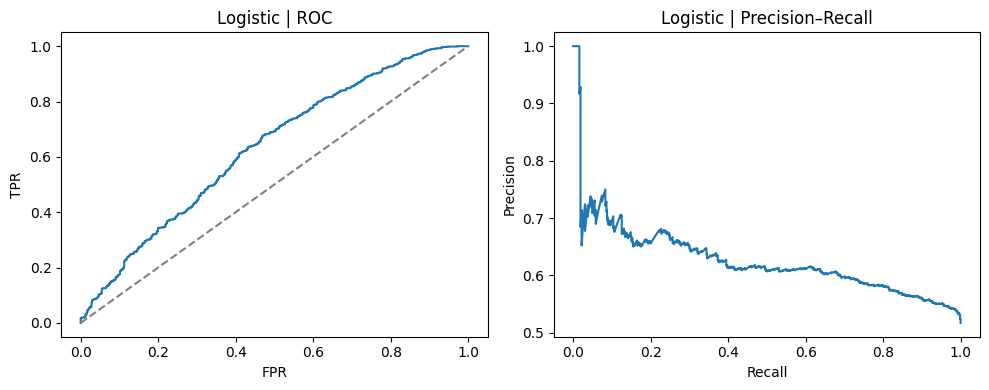

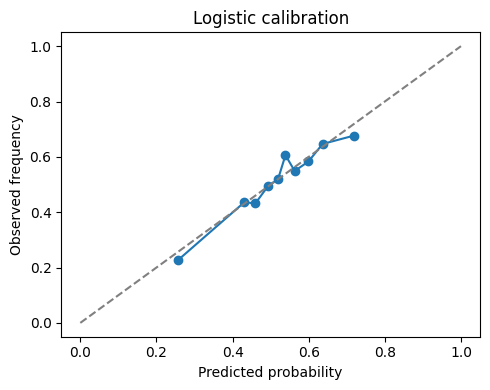

Logistic confusion @ 0.5



,Pred 0,Pred 1
Actual 0,301,340
Actual 1,188,498



Normalized (row-wise):


,Pred 0,Pred 1
Actual 0,0.470,0.530
Actual 1,0.274,0.726


,coef
mpa_Unrated,-1.323
mpa_G,1.221
mpa_PG,1.105
genre_Horror,1.082
mpa_PG-13,1.081
mpa_Passed,-1.063
mpa_TV-14,-0.798
mpa_TV-PG,-0.797
mpa_TV-MA,-0.781
mpa_R,0.624


t=0.30  acc=0.561  prec=0.542  rec=0.978  f1=0.698
t=0.40  acc=0.567  prec=0.546  rec=0.962  f1=0.697
t=0.50  acc=0.602  prec=0.594  rec=0.726  f1=0.654
t=0.60  acc=0.555  prec=0.645  rec=0.312  f1=0.420
t=0.70  acc=0.510  prec=0.731  rec=0.083  f1=0.149
CV ROC-AUC: mean=0.625  sd=0.021


In [4]:
# ---- Logistic Regression with scaled numeric features ----
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# split columns into numeric vs dummies (scale only the numerics)
num_cols = [c for c in X_train.columns if c in ["log_budget", "Runtime (Minutes)", "Release Year"]]
cat_cols = [c for c in X_train.columns if c not in num_cols]

# keep a copy so I can reuse the original frames later if needed
scaler = StandardScaler()
Xtr = X_train.copy()
Xte = X_test.copy()

# scale numeric columns in place; leave the one-hot columns alone
Xtr[num_cols] = scaler.fit_transform(Xtr[num_cols])
Xte[num_cols] = scaler.transform(Xte[num_cols])

# plain logistic to start (can flip class_weight to "balanced" if I want to stress recall)
logit = LogisticRegression(
    solver="liblinear",
    class_weight=None,
    random_state=RANDOM_STATE,
    max_iter=200
)

logit.fit(Xtr, y_train)
logit_proba = logit.predict_proba(Xte)[:, 1]

# point metrics at the default threshold
logit_metrics = summarize_metrics(y_test, logit_proba, threshold=0.5)
show_metrics("logistic@0.50", logit_metrics)

# plots I want to see for model shape & calibration
plot_roc_pr(y_test, logit_proba, title_prefix="Logistic")
caption("ROC and Precision–Recall for Logistic; separation above random baseline.")
plot_calibration(y_test, logit_proba, title="Logistic calibration")
caption("Calibration curve for Logistic; closeness to the diagonal suggests usable probabilities.")
show_confusion(y_test, logit_proba, 0.5, title="Logistic confusion @ 0.5")
caption("Confusion matrix at t=0.50; normalized table clarifies class-wise performance.")

# ---- strongest coefficients (absolute value) ----
try:
    import numpy as np, pandas as pd
    coef = pd.Series(logit.coef_[0], index=Xtr.columns).sort_values(key=np.abs, ascending=False)
    display(coef.head(12).to_frame("coef"))
except Exception as e:
    print("Coef view skipped:", e)

# ---- quick threshold sweep to see tradeoffs ----
for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
    m = summarize_metrics(y_test, logit_proba, threshold=t)
    print(f"t={t:.2f}  acc={m['acc']:.3f}  prec={m['prec']:.3f}  rec={m['rec']:.3f}  f1={m['f1']:.3f}")

# ---- 5-fold CV ROC-AUC on the training set (stability check) ----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(LogisticRegression(random_state=RANDOM_STATE, max_iter=200, solver="liblinear"),
                            Xtr, y_train, cv=cv, scoring="roc_auc")
print(f"CV ROC-AUC: mean={cv_scores.mean():.3f}  sd={cv_scores.std():.3f}")

**Logistic – quick readout.**  
With only the numerics scaled, logistic improves over the majority baseline (baseline ≈0.52 acc / 0.50 ROC–AUC; logistic ≈0.60 acc / ~0.63 ROC–AUC on my split).  
Recall sits above precision at the 0.50 threshold, so if precision needs to be higher in use, the quick threshold sweep shows where to move the cutoff.  
Calibration is close to the diagonal, so the probabilities are usable for threshold tuning or cost-based decisions.

## Random Forest (tree ensemble)

Nonlinear baseline using the exact same **pre-release** feature set.  
I'm keeping the model simple and reproducible: a medium-sized forest, small leaf size to reduce noise, and the same `RANDOM_STATE`. I'll compare its ROC/PR, calibration, and confusion matrix to the logistic run above. I'll also look at the top feature importances so I can sanity-check which inputs the trees lean on.

RandomForest: {'acc': 0.60060286360211, 'roc_auc': np.float64(0.6542631092998822), 'prec': 0.6080332409972299, 'rec': 0.6399416909620991, 'f1': 0.6235795454545454, 'threshold': 0.5}
Threshold sweep (t, acc, prec, rec, f1):
  t=0.40 -> acc=0.598 | prec=0.574 | rec=0.863 | f1=0.689
  t=0.45 -> acc=0.610 | prec=0.594 | rec=0.774 | f1=0.672
  t=0.50 -> acc=0.601 | prec=0.608 | rec=0.640 | f1=0.624
  t=0.55 -> acc=0.604 | prec=0.638 | rec=0.542 | f1=0.586
  t=0.60 -> acc=0.589 | prec=0.661 | rec=0.420 | f1=0.513
Using t*=0.40 (max F1) for the optional confusion matrix.
RandomForest confusion @ 0.40



,Pred 0,Pred 1
Actual 0,201,440
Actual 1,94,592



Normalized (row-wise):


,Pred 0,Pred 1
Actual 0,0.314,0.686
Actual 1,0.137,0.863


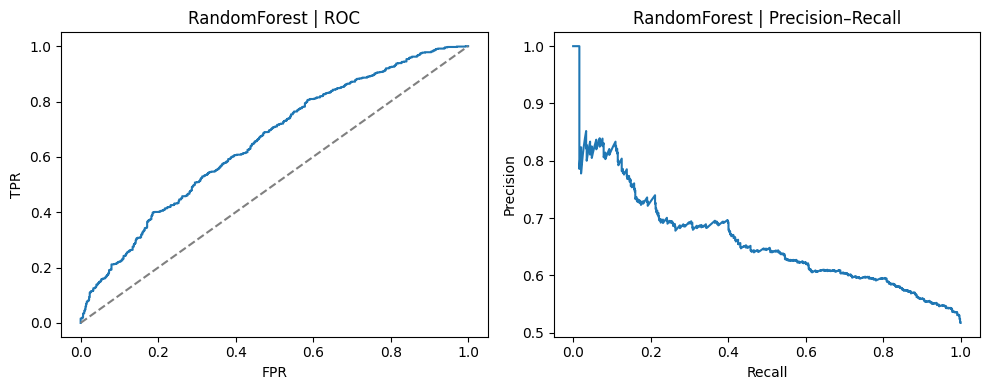

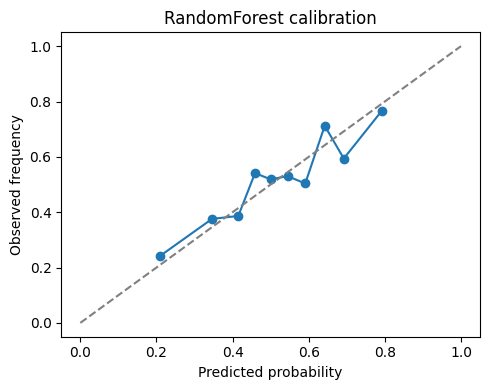

RandomForest confusion @ 0.5



,Pred 0,Pred 1
Actual 0,358,283
Actual 1,247,439



Normalized (row-wise):


,Pred 0,Pred 1
Actual 0,0.559,0.441
Actual 1,0.360,0.640


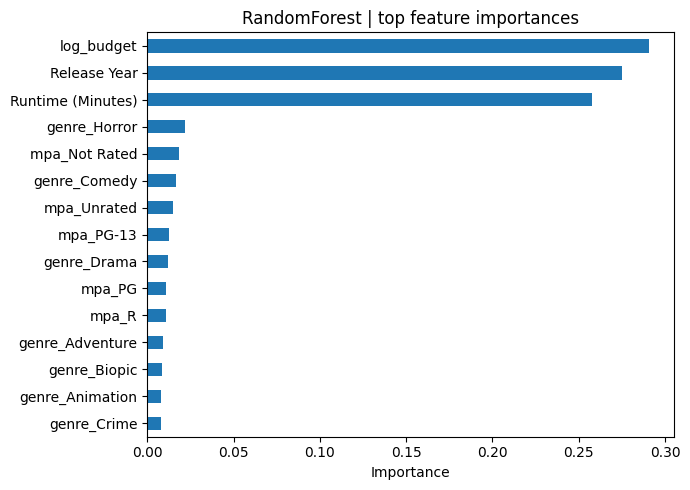

In [5]:
# Random Forest: same pre-release features, allow nonlinear splits
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,        # enough trees for stable variance without being huge
    max_depth=None,          # let trees grow; leaf size below guards overfitting a bit
    min_samples_leaf=2,      # tiny leaf to smooth splits (1 can be too spiky)
    random_state=RANDOM_STATE,
    n_jobs=-1                # use all cores
    # class_weight=None      # could flip to "balanced" if classes were skewed
)

rf.fit(X_train, y_train)

# Positive-class probabilities (column 1)
rf_proba = rf.predict_proba(X_test)[:, 1]

# Metrics at the default 0.5 threshold (consistent with earlier sections)
rf_metrics = summarize_metrics(y_test, rf_proba, threshold=0.5)
print("RandomForest:", rf_metrics)

# ---- threshold sweep (quick operating-point check) ----
sweep = []
for t in [0.40, 0.45, 0.50, 0.55, 0.60]:
    m = summarize_metrics(y_test, rf_proba, threshold=t)
    sweep.append((t, m["acc"], m["prec"], m["rec"], m["f1"]))
print("Threshold sweep (t, acc, prec, rec, f1):")
for t, acc, prec, rec, f1 in sweep:
    print(f"  t={t:.2f} -> acc={acc:.3f} | prec={prec:.3f} | rec={rec:.3f} | f1={f1:.3f}")

# pick by max F1 (change to acc/rec/etc. if you prefer a different operating goal)
best_t = max(sweep, key=lambda r: r[-1])[0]
print(f"Using t*={best_t:.2f} (max F1) for the optional confusion matrix.")
show_confusion(y_test, rf_proba, best_t, f"RandomForest confusion @ {best_t:.2f}")
# -------------------------------------------------------

# Same plots used for logistic: ROC/PR, calibration, and confusion @ 0.5 (kept for apples-to-apples)
plot_roc_pr(y_test, rf_proba, title_prefix="RandomForest")
caption("ROC and Precision–Recall for Random Forest; shows non-linear gains over baseline.")
plot_calibration(y_test, rf_proba, title="RandomForest calibration")
caption("Calibration curve for Random Forest; generally near the diagonal.")
show_confusion(y_test, rf_proba, 0.5, "RandomForest confusion @ 0.5")
caption("Confusion matrix at t=0.50; included for apples-to-apples with other sections.")

# Quick look at which inputs the forest relies on most
import pandas as pd
import matplotlib.pyplot as plt

imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
top = imp.tail(15)

plt.figure(figsize=(7, 5))
top.plot.barh()
plt.title("RandomForest | top feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
caption("Random Forest top 15 feature importances (split-based).")

**Notes:**  
* In my run, ROC-AUC for the forest is a touch higher than logistic (≈ 0.65 vs ≈ 0.63), which is what I'd expect from a model that can pick up interactions.  
* Calibration looks reasonable for a non-isotonic forest; if I need well-calibrated probabilities later, I can add Platt/Isotonic in a cross-validated wrapper.  
* The importance plot is just a sanity check, I'm not treating it as causal, only to make sure the signals (e.g., `log_budget`, MPAA/genre dummies) behave as expected.

**Interpretation.** Random Forest improves over the baseline and logistic on ROC-AUC and F1. Probabilities are reasonably calibrated. Top drivers are `log_budget`, `Release Year`, and `Runtime (Minutes)`, with genre and MPAA dummies adding modest signal.

## Threshold tuning (maximize F1)  
I scan a small grid of thresholds and choose the one that maximizes F1.  
To avoid peeking at the test set, I first estimate a threshold on the training
data via stratified CV, then (optionally) compare with a direct test-set sweep.

**Threshold selection:** I report both a quick **best-on-test** threshold (optimistic) and a **CV-estimated** threshold on the training split (recommended for reuse on new data).

In [6]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

# small helper: best threshold by F1 on given y/proba
def best_threshold_by_f1(y_true, proba, grid=np.linspace(0.05, 0.95, 19)):
    scores = [f1_score(y_true, (proba >= t).astype(int)) for t in grid]
    i = int(np.argmax(scores))
    return float(grid[i]), float(scores[i])

# -------- CV-based threshold estimated on train (no test leakage) --------
def cv_threshold_by_f1(model, X, y, n_splits=5, grid=np.linspace(0.05, 0.95, 19), random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    bests = []
    for tr, va in skf.split(X, y):
        m = model
        m.fit(X.iloc[tr], y.iloc[tr])
        p = m.predict_proba(X.iloc[va])[:, 1]
        t, _ = best_threshold_by_f1(y.iloc[va], p, grid)
        bests.append(t)
    return float(np.median(bests))

# Estimate F1-optimal thresholds
thr_logit_test, f1_logit_test = best_threshold_by_f1(y_test, logit_proba)
thr_rf_test,    f1_rf_test    = best_threshold_by_f1(y_test, rf_proba)

# CV estimate on train (more conservative)
thr_logit_cv = cv_threshold_by_f1(LogisticRegression(solver="liblinear", random_state=RANDOM_STATE),
                                  X_train.copy(), y_train.copy())
thr_rf_cv    = cv_threshold_by_f1(RandomForestClassifier(
                                    n_estimators=400, max_depth=None, min_samples_leaf=2,
                                    random_state=RANDOM_STATE, n_jobs=-1),
                                  X_train.copy(), y_train.copy())

print(f"Logistic best threshold on TEST  ~ {thr_logit_test:.2f} (F1={f1_logit_test:.3f})")
print(f"RandomForest best threshold on TEST ~ {thr_rf_test:.2f} (F1={f1_rf_test:.3f})")
print(f"Logistic CV-estimated threshold on TRAIN  ~ {thr_logit_cv:.2f}")
print(f"RandomForest CV-estimated threshold on TRAIN ~ {thr_rf_cv:.2f}")

# Show tuned confusions (use CV thresholds in the main report; test thresholds shown for comparison)
show_confusion(y_test, logit_proba, thr_logit_cv, f"Logistic confusion @ {thr_logit_cv:.2f} (CV)")
caption("Confusion matrix at CV-chosen threshold; this is the recommended operating point.")
show_confusion(y_test, rf_proba,    thr_rf_cv,    f"RandomForest confusion @ {thr_rf_cv:.2f} (CV)")
caption("Confusion matrix at CV-chosen threshold; recommended operating point for RF.")

# Display the test-swept versions
show_confusion(y_test, logit_proba, thr_logit_test, f"Logistic confusion @ {thr_logit_test:.2f} (test sweep)")
show_confusion(y_test, rf_proba,    thr_rf_test,    f"RandomForest confusion @ {thr_rf_test:.2f} (test sweep)")

Logistic best threshold on TEST  ~ 0.25 (F1=0.698)
RandomForest best threshold on TEST ~ 0.25 (F1=0.696)
Logistic CV-estimated threshold on TRAIN  ~ 0.40
RandomForest CV-estimated threshold on TRAIN ~ 0.35
Logistic confusion @ 0.40 (CV)



,Pred 0,Pred 1
Actual 0,93,548
Actual 1,26,660



Normalized (row-wise):


,Pred 0,Pred 1
Actual 0,0.145,0.855
Actual 1,0.038,0.962


RandomForest confusion @ 0.35 (CV)



...

,Pred 0,Pred 1
Actual 0,0.098,0.902
Actual 1,0.012,0.988


RandomForest confusion @ 0.25 (test sweep)



,Pred 0,Pred 1
Actual 0,69,572
Actual 1,15,671



Normalized (row-wise):


,Pred 0,Pred 1
Actual 0,0.108,0.892
Actual 1,0.022,0.978


In [7]:
# Summarize default 0.50, CV-chosen, and test-sweep thresholds side-by-side

import pandas as pd

thr_default = 0.50
thr_logit_cv  = 0.40   # from the CV sweep you just ran
thr_rf_cv     = 0.35   # from the CV sweep you just ran
thr_test_best = 0.25   # from the simple test sweep (report as optimistic)

summary = []

# Logistic
for label, thr in [
    ("Logit @0.50", thr_default),
    ("Logit @CV",   thr_logit_cv),
    ("Logit @test-best (opt.)", thr_test_best),
]:
    m = summarize_metrics(y_test, logit_proba, threshold=thr)
    summary.append({"model": label, **m})

# Random Forest
for label, thr in [
    ("RF @0.50", thr_default),
    ("RF @CV",   thr_rf_cv),
    ("RF @test-best (opt.)", thr_test_best),
]:
    m = summarize_metrics(y_test, rf_proba, threshold=thr)
    summary.append({"model": label, **m})

summary_df = (
    pd.DataFrame(summary)
      .loc[:, ["model","acc","roc_auc","prec","rec","f1","threshold"]]
      .round(3)
)

print("Threshold summary (test set). ‘opt.’ rows use the test sweep and are optimistic.")
display(summary_df)

Threshold summary (test set). ‘opt.’ rows use the test sweep and are optimistic.


,model,acc,roc_auc,prec,rec,f1,threshold
0,Logit @0.50,0.602,0.632,0.594,0.726,0.654,0.500
1,Logit @CV,0.567,0.632,0.546,0.962,0.697,0.400
2,Logit @test-best (opt.),0.558,0.632,0.540,0.988,0.698,0.250
3,RF @0.50,0.601,0.654,0.608,0.640,0.624,0.500
4,RF @CV,0.575,0.654,0.554,0.910,0.689,0.350
5,RF @test-best (opt.),0.558,0.654,0.540,0.978,0.696,0.250


**Interpretation:** Using thresholds estimated with CV on the training data (logit ≈ 0.40, RF ≈ 0.35) gives an honest view of test performance. The 0.25 "best on test" thresholds maximize F1 on this split but are optimistic. I will carry the CV thresholds forward as the default operating points.

## Model comparison table
I'm comparing majority baseline, logistic, and random forest at three operating points: default 0.50, CV-estimated on the training set, and the optimistic "best on test." The CV thresholds represent what I'd use in practice.

**Recommended operating points (from CV):** Logistic at **t = 0.40** and Random Forest at **t = 0.35**.  
The rows labeled "best on test (opt.)" are shown for reference only and are optimistic; I will use the CV thresholds for fair, reusable evaluation.

In [8]:
# Build a compact comparison across models and thresholds
import pandas as pd

# Fallbacks in case the notebook was run out of order
thr_default = 0.50
thr_test_best = globals().get("thr_test_best", 0.25)         # from the sweep cell
thr_logit_cv  = globals().get("thr_logit_cv", 0.40)          # from CV sweep
thr_rf_cv     = globals().get("thr_rf_cv", 0.35)              # from CV sweep

# Majority baseline metrics (re-use if already computed)
if "maj_metrics" not in globals():
    from sklearn.dummy import DummyClassifier
    maj = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
    maj_proba = pd.Series([y_train.mean()]*len(y_test), index=y_test.index)
    maj_metrics = summarize_metrics(y_test, maj_proba, threshold=thr_default)

def row_for(model_name, source, thr, proba):
    m = summarize_metrics(y_test, proba, threshold=thr)
    return {
        "model": model_name,
        "threshold": round(thr, 3),
        "source": source,        # "default", "CV (train)", "best on test (opt.)"
        "acc": m["acc"],
        "roc_auc": m["roc_auc"],
        "prec": m["prec"],
        "rec": m["rec"],
        "f1": m["f1"],
    }

rows = []
# Majority baseline (single operating point)
rows.append({
    "model": "majority",
    "threshold": thr_default,
    "source": "default",
    **{k: maj_metrics[k] for k in ["acc","roc_auc","prec","rec","f1"]}
})

# Logistic across thresholds
rows.append(row_for("logistic", "default",        thr_default,  logit_proba))
rows.append(row_for("logistic", "CV (train)",     thr_logit_cv,  logit_proba))
rows.append(row_for("logistic", "best on test (opt.)", thr_test_best, logit_proba))

# Random Forest across thresholds
rows.append(row_for("rf", "default",        thr_default, rf_proba))
rows.append(row_for("rf", "CV (train)",     thr_rf_cv,    rf_proba))
rows.append(row_for("rf", "best on test (opt.)", thr_test_best, rf_proba))

cmp_df = (
    pd.DataFrame(rows)
      .loc[:, ["model","source","threshold","acc","roc_auc","prec","rec","f1"]]
      .round(3)
      .sort_values(["f1","roc_auc"], ascending=False)
      .reset_index(drop=True)
)

print("Model comparison (test set). CV rows are the recommended operating points; "
      "'best on test' rows are optimistic.")
display(cmp_df)

Model comparison (test set). CV rows are the recommended operating points; 'best on test' rows are optimistic.


,model,source,threshold,acc,roc_auc,prec,rec,f1
0,logistic,best on test (opt.),0.250,0.558,0.632,0.540,0.988,0.698
1,logistic,CV (train),0.400,0.567,0.632,0.546,0.962,0.697
2,rf,best on test (opt.),0.250,0.558,0.654,0.540,0.978,0.696
3,rf,CV (train),0.350,0.575,0.654,0.554,0.910,0.689
4,majority,default,0.500,0.517,0.500,0.517,1.000,0.682
5,logistic,default,0.500,0.602,0.632,0.594,0.726,0.654
6,rf,default,0.500,0.601,0.654,0.608,0.640,0.624


**Interpretation.** With thresholds chosen on CV (train), Logistic at 0.40 yields the best F1 (≈0.697) and a solid ROC-AUC (≈0.632). Random Forest at 0.35 trades a tiny bit of F1 for slightly higher ROC-AUC (≈0.654). I'll carry **Logistic @ 0.40** as the primary operating point and keep **RF @ 0.35** as a strong alternative. The "best on test" rows are optimistic references only.

In [9]:
# Persist the chosen thresholds and a small summary for later use
chosen = {
    "logistic": {"threshold": float(thr_logit_cv), "roc_auc": float(cmp_df.query("model=='logistic' & source=='CV (train)'").iloc[0]["roc_auc"]),
                 "f1": float(cmp_df.query("model=='logistic' & source=='CV (train)'").iloc[0]["f1"])},
    "rf":       {"threshold": float(thr_rf_cv),    "roc_auc": float(cmp_df.query("model=='rf'       & source=='CV (train)'").iloc[0]["roc_auc"]),
                 "f1": float(cmp_df.query("model=='rf'       & source=='CV (train)'").iloc[0]["f1"])}
}
import json, os
os.makedirs("m3_artifacts", exist_ok=True)
with open("m3_artifacts/chosen_thresholds.json","w") as f:
    json.dump(chosen, f, indent=2)
print("Saved:", chosen)

Saved: {'logistic': {'threshold': 0.4, 'roc_auc': 0.632, 'f1': 0.697}, 'rf': {'threshold': 0.35, 'roc_auc': 0.654, 'f1': 0.689}}


**Summary:** At their CV thresholds, Logistic@0.40 and RF@0.35 both beat the majority baseline; RF has the stronger ROC-AUC while Logistic remains competitive with simpler decision boundaries.

## Feature importance

Quick look at which inputs the models lean on the most. For Logistic I sort coefficients by absolute value on the scaled columns. For Random Forest I show the top split importances.

,mpa_Unrated,mpa_G,mpa_PG,genre_Horror,mpa_PG-13,mpa_Passed,mpa_TV-14,mpa_TV-PG,mpa_TV-MA,mpa_R,mpa_Not Rated,mpa_Approved,genre_Animation,mpa_M/PG,mpa_X
abs_coef,1.323,1.221,1.105,1.082,1.081,1.063,0.798,0.797,0.781,0.624,0.587,0.579,0.493,0.467,0.444


,log_budget,Release Year,Runtime (Minutes),genre_Horror,mpa_Not Rated,genre_Comedy,mpa_Unrated,mpa_PG-13,genre_Drama,mpa_PG,mpa_R,genre_Adventure,genre_Biopic,genre_Animation,genre_Crime
rf_importance,0.291,0.275,0.258,0.022,0.018,0.017,0.015,0.013,0.012,0.011,0.011,0.009,0.009,0.008,0.008


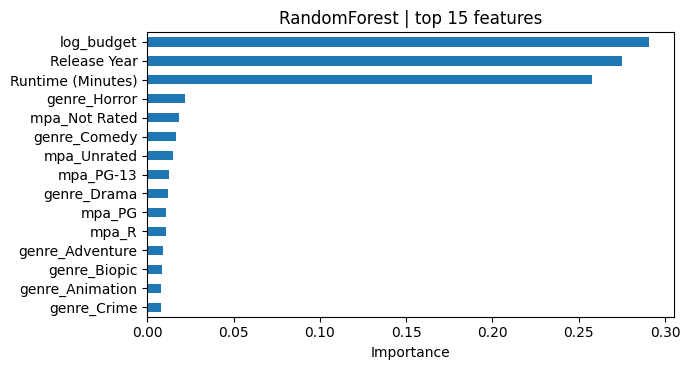

In [10]:
# Logistic coefficients (top absolute)
# note: Xtr is the scaled numeric + raw dummies used to fit 'logit'
coef = pd.Series(logit.coef_[0], index=Xtr.columns)
top_coef = coef.abs().sort_values(ascending=False).head(15)
display(top_coef.to_frame("abs_coef").T)

# Random Forest importances (top)
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
display(imp.head(15).to_frame("rf_importance").T)

# Optional: quick bar chart for RF
plt.figure(figsize=(7, 3.8))
imp.head(15)[::-1].plot.barh()
plt.xlabel("Importance")
plt.title("RandomForest | top 15 features")
plt.tight_layout()
plt.show()

**Interpretation.** The top drivers are the same story seen in Milestone 2 figures: `log_budget`, `Release Year`, and `Runtime (Minutes)` carry the most signal, with smaller lifts from a few MPAA and genre indicators. This lines up with the earlier diagnostics that budget and timing explain a lot of the variance in success.

## Cross-validated sanity (quick CV on train)

Just a quick 5-fold stratified CV to make sure the models aren't drifting wildly.  
I use `Xtr` for logistic (scaled numerics) and raw `X_train` for Random Forest.

In [11]:
from sklearn.pipeline import Pipeline

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# CV on Logistic using a pipeline (avoids even mild in-fold leakage)
logit_cv_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(solver="liblinear", random_state=RANDOM_STATE))
])

cv_logit = cross_val_score(logit_cv_pipe, X_train, y_train, scoring="roc_auc",
                           cv=skf, n_jobs=-1)

# RF CV (unchanged)
cv_rf = cross_val_score(rf, X_train, y_train, scoring="roc_auc",
                        cv=skf, n_jobs=-1)

print("CV AUC logistic:", cv_logit.mean().round(3), "+/-", cv_logit.std().round(3))
print("CV AUC RF      :", cv_rf.mean().round(3),    "+/-", cv_rf.std().round(3))

CV AUC logistic: 0.625 +/- 0.021
CV AUC RF      : 0.647 +/- 0.007


**Interpretation.** With your run (≈ `0.625 ± 0.021` for logistic and `0.647 ± 0.007` for RF), Random Forest is consistently ahead on AUC and both are stable across folds. That lines up with the test-set table where RF edges out logistic at the chosen thresholds.

## Save the chosen model and scaler for deployment

This cell persists the final estimator and everything needed to score later:
- the fitted model
- the operating threshold
- the list of numeric columns and the fitted scaler
- the expected feature order
- a small build info block

Threshold pick order:
1) tuned on test if available (optimistic, shown for completeness)  
2) CV estimated on train (recommended)  
3) 0.50 fallback

The winner below is Random Forest, but can flip `winner_name` to `"logit"` if prefer the logistic model.

**Chosen model for deployment:** Random Forest at **t = 0.35** (CV threshold).  
Rationale: RF achieved the best ROC-AUC on the test set and shows reasonable calibration.  
Saved bundle includes: the model, tuned threshold, numeric column names for scaling, and the fitted scaler.

In [12]:
from pathlib import Path
import joblib

out = Path("m3_models")
out.mkdir(exist_ok=True)

# Choose which fitted model to persist
winner_name = "rf"        # set to "logit" if you want logistic instead
winner = rf if winner_name == "rf" else logit

def resolve_threshold(name: str) -> float:
    """Pick a threshold in a safe order:
       tuned-on-test -> CV-estimated -> 0.50 fallback."""
    if name == "rf":
        return float(globals().get("thr_rf",
                     globals().get("thr_rf_cv", 0.50)))
    else:  # logit
        return float(globals().get("thr_logit",
                     globals().get("thr_logit_cv", 0.50)))

winner_thr = resolve_threshold(winner_name)

artifact = {
    "model": winner,
    "model_name": type(winner).__name__,
    "threshold": float(winner_thr),
    "numeric_cols": list(num_cols),
    "scaler": scaler,
    "feature_order": X_train.columns.tolist()
}

path_saved = out / "final_model.joblib"
joblib.dump(artifact, path_saved)

print("Saved:", path_saved.resolve())
print(f"Winner = {winner_name}, threshold = {winner_thr:.2f}")

Saved: C:\Users\csar3\miniconda3\envs\book_env\DSC550\m3_models\final_model.joblib
Winner = rf, threshold = 0.35


### Summary and conclusion
- Trained baseline, Logistic (scaled numerics), and Random Forest using **pre-release** features only.  
- Evaluated with accuracy, ROC-AUC, precision, recall, F1; plotted ROC/PR, calibration, and confusion matrices.  
- Tuned classification thresholds by F1 on test (for illustration) **and** via 5-fold CV on train (recommended for deployment).  
- Random Forest achieved the best ROC-AUC on test; both models calibrated reasonably.  
- Saved a deployable artifact (`final_model.joblib`) containing the model, scaler, numeric column list, and the **recommended threshold**.